In [ ]:
!pip install -q scikit-learn pandas seaborn tqdm

In [ ]:
import os, sys, json, random, warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from tqdm.auto import tqdm
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset, Dataset
import torchvision.transforms as transforms
import torchvision.models as models

from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    classification_report, confusion_matrix
)
from sklearn.manifold import TSNE

print(f"PyTorch: {torch.__version__}")

PyTorch: 2.10.0+cu128


In [ ]:
!pip install kagglehub[pandas-datasets]

In [ ]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

In [ ]:
path = kagglehub.dataset_download("ashery/chexpert")
print(f"Downloaded to: {path}")

Using Colab cache for faster access to the 'chexpert' dataset.
Downloaded to: /kaggle/input/chexpert


In [ ]:
import os
for root, dirs, files in os.walk(path):
    # Only show first 2 levels
    depth = root.replace(path, "").count(os.sep)
    if depth < 2:
        indent = "  " * depth
        print(f"{indent}{os.path.basename(root)}/")
        for f in files[:10]:
            print(f"{indent}  {f}")
        if len(files) > 10:
            print(f"{indent}  ... and {len(files)-10} more files")

chexpert/
  valid.csv
  train.csv
  valid/
  train/


KeyboardInterrupt: 

In [ ]:
import pandas as pd

# Adjust this based on what the download prints
data_dir = os.path.join(path)

df_train = pd.read_csv(os.path.join(data_dir, "train.csv"))
df_valid = pd.read_csv(os.path.join(data_dir, "valid.csv"))

print(f"Train: {len(df_train)} rows, Valid: {len(df_valid)} rows")
print(df_train.head())

Train: 223414 rows, Valid: 234 rows
                                                Path     Sex  Age  \
0  CheXpert-v1.0-small/train/patient00001/study1/...  Female   68   
1  CheXpert-v1.0-small/train/patient00002/study2/...  Female   87   
2  CheXpert-v1.0-small/train/patient00002/study1/...  Female   83   
3  CheXpert-v1.0-small/train/patient00002/study1/...  Female   83   
4  CheXpert-v1.0-small/train/patient00003/study1/...    Male   41   

  Frontal/Lateral AP/PA  No Finding  Enlarged Cardiomediastinum  Cardiomegaly  \
0         Frontal    AP         1.0                         NaN           NaN   
1         Frontal    AP         NaN                         NaN          -1.0   
2         Frontal    AP         NaN                         NaN           NaN   
3         Lateral   NaN         NaN                         NaN           NaN   
4         Frontal    AP         NaN                         NaN           NaN   

   Lung Opacity  Lung Lesion  Edema  Consolidation  Pneumonia 

In [ ]:
# The 5 CheXpert competition pathologies
COMPETITION_TASKS = ["Atelectasis", "Cardiomegaly", "Consolidation", "Edema", "Pleural Effusion"]
CLASS_NAMES = ["No Finding"] + COMPETITION_TASKS  # 6 classes total

config = {
    # Dataset
    "dataset":     "chexpert_small",
    "data_dir":    data_dir,
    "num_classes": len(CLASS_NAMES),
    "image_size":  224,
    "num_workers": 4,
    "class_names": CLASS_NAMES,

    # Training
    "batch_size":    32,
    "epochs":        15,
    "lr":            1e-4,
    "weight_decay":  1e-4,
    "seed":          42,

    # Model
    "model_name":  "resnet18",
    "mc_dropout_p": 0.3,
    "mc_samples":   30,

    # Distribution shift simulation
    "shift_noise_std": 0.3,
    "shift_blur_k":    5,
    # Holdout classes for Type B: Consolidation and Edema (indices 3,4 in CLASS_NAMES)
    "holdout_classes": [3, 4],

    # Temperature scaling
    "temp_lr":     0.01,
    "temp_epochs": 200,

    # Device
    "device": "cuda" if torch.cuda.is_available() else "cpu",

    # Outputs
    "checkpoint_dir": "./checkpoints",
    "results_dir":    "./results",
}

for d in [config["checkpoint_dir"], config["results_dir"]]:
    Path(d).mkdir(parents=True, exist_ok=True)

print(json.dumps({k: v for k, v in config.items() if k != "device"}, indent=2))
print(f"Device: {config['device']}")

{
  "dataset": "chexpert_small",
  "data_dir": "/kaggle/input/chexpert",
  "num_classes": 6,
  "image_size": 224,
  "num_workers": 4,
  "class_names": [
    "No Finding",
    "Atelectasis",
    "Cardiomegaly",
    "Consolidation",
    "Edema",
    "Pleural Effusion"
  ],
  "batch_size": 32,
  "epochs": 15,
  "lr": 0.0001,
  "weight_decay": 0.0001,
  "seed": 42,
  "model_name": "resnet18",
  "mc_dropout_p": 0.3,
  "mc_samples": 30,
  "shift_noise_std": 0.3,
  "shift_blur_k": 5,
  "holdout_classes": [
    3,
    4
  ],
  "temp_lr": 0.01,
  "temp_epochs": 200,
  "checkpoint_dir": "./checkpoints",
  "results_dir": "./results"
}
Device: cuda


In [ ]:
config["data_dir"] = data_dir

## 2. Reproducibility

In [ ]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(config["seed"])

In [ ]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

def get_train_transforms(sz):
    return transforms.Compose([
        transforms.Resize((sz, sz)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ColorJitter(brightness=0.15, contrast=0.15),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])

def get_val_transforms(sz):
    return transforms.Compose([
        transforms.Resize((sz, sz)),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])

In [ ]:
class CheXpertDataset(Dataset):
    """CheXpert dataset: single-label version for selective classification."""

    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(self.labels[idx], dtype=torch.long)


def prepare_chexpert_df(csv_path, data_root, tasks, frontal_only=True):
    """Load and preprocess a CheXpert CSV file.

    Returns a DataFrame with columns: path (absolute), label (int 0..len(tasks)).
    Class 0 = No Finding, classes 1..5 = competition tasks.
    """
    df = pd.read_csv(csv_path)

    # Filter to frontal views only
    if frontal_only and "Frontal/Lateral" in df.columns:
        df = df[df["Frontal/Lateral"] == "Frontal"].copy()

    # U-Ones: map uncertain (-1) to positive (1), blank/NaN to 0
    for t in tasks:
        df[t] = df[t].fillna(0.0)
        df[t] = df[t].replace(-1.0, 1.0)

    # Handle "No Finding" column
    if "No Finding" in df.columns:
        df["No Finding"] = df["No Finding"].fillna(0.0)
    else:
        df["No Finding"] = 0.0

    # Assign single label: pick the dominant pathology
    # Priority: rarest class first (to help imbalance)
    task_counts = {t: (df[t] == 1.0).sum() for t in tasks}
    tasks_by_rarity = sorted(tasks, key=lambda t: task_counts[t])

    labels = []
    for _, row in df.iterrows():
        assigned = 0  # default: No Finding
        if row.get("No Finding", 0) == 1.0:
            assigned = 0
        else:
            for t in tasks_by_rarity:
                if row[t] == 1.0:
                    assigned = tasks.index(t) + 1  # +1 because 0 = No Finding
                    break
        labels.append(assigned)

    df["label"] = labels

    # Build absolute image paths
    # CheXpert CSV paths look like: CheXpert-v1.0-small/train/patient.../study.../view.jpg
    # We need to prepend the parent directory of CheXpert-v1.0-small
    parent_dir = str(Path(data_root).parent)
    df["abs_path"] = df["Path"].apply(lambda p: os.path.join(parent_dir, p))

    # Verify a few paths exist
    sample_paths = df["abs_path"].head(5).tolist()
    found = sum(os.path.isfile(p) for p in sample_paths)
    if found == 0:
        # Try alternate: paths relative to data_root
        df["abs_path"] = df["Path"].apply(
            lambda p: os.path.join(data_root, *p.split("/")[1:])
        )
        found = sum(os.path.isfile(p) for p in df["abs_path"].head(5).tolist())
        if found == 0:
            print(f"WARNING: Could not resolve image paths. Sample: {sample_paths[0]}")

    # Filter out missing images
    exists_mask = df["abs_path"].apply(os.path.isfile)
    n_missing = (~exists_mask).sum()
    if n_missing > 0:
        print(f"  Skipping {n_missing} images with missing files")
        df = df[exists_mask].copy()

    print(f"  Loaded {len(df)} frontal images")
    for i, name in enumerate(["No Finding"] + tasks):
        n = (df["label"] == i).sum()
        print(f"    {name}: {n} ({n/len(df)*100:.1f}%)")

    return df


def get_chexpert_loaders(config):
    """Build train/val/test dataloaders for CheXpert Small."""
    data_dir = config["data_dir"]
    sz = config["image_size"]
    bs = config["batch_size"]
    nw = config["num_workers"]
    pin = torch.cuda.is_available()

    train_csv = os.path.join(data_dir, "train.csv")
    valid_csv = os.path.join(data_dir, "valid.csv")

    print("Processing training set...")
    df_train_full = prepare_chexpert_df(train_csv, data_dir, COMPETITION_TASKS)

    print("\nProcessing validation set...")
    df_valid = prepare_chexpert_df(valid_csv, data_dir, COMPETITION_TASKS)

    # Split training set into train (90%) and val (10%), use official valid as test
    from sklearn.model_selection import train_test_split
    idx_all = np.arange(len(df_train_full))
    labels_all = df_train_full["label"].values

    idx_train, idx_val = train_test_split(
        idx_all, test_size=0.10, stratify=labels_all, random_state=config["seed"]
    )

    train_paths  = df_train_full["abs_path"].values[idx_train]
    train_labels = labels_all[idx_train]
    val_paths    = df_train_full["abs_path"].values[idx_val]
    val_labels   = labels_all[idx_val]
    test_paths   = df_valid["abs_path"].values
    test_labels  = df_valid["label"].values

    train_ds = CheXpertDataset(train_paths, train_labels, get_train_transforms(sz))
    val_ds   = CheXpertDataset(val_paths,   val_labels,   get_val_transforms(sz))
    test_ds  = CheXpertDataset(test_paths,  test_labels,  get_val_transforms(sz))

    train_loader = DataLoader(train_ds, batch_size=bs, shuffle=True,  num_workers=nw, pin_memory=pin)
    val_loader   = DataLoader(val_ds,   batch_size=bs, shuffle=False, num_workers=nw, pin_memory=pin)
    test_loader  = DataLoader(test_ds,  batch_size=bs, shuffle=False, num_workers=nw, pin_memory=pin)

    print(f"\nCheXpert Small: train={len(train_ds)} val={len(val_ds)} test={len(test_ds)}")
    print(f"Classes ({config['num_classes']}): {CLASS_NAMES}")
    return train_loader, val_loader, test_loader


train_loader, val_loader, test_loader = get_chexpert_loaders(config)
print(f"\nUsing {config['num_classes']} classes: {CLASS_NAMES}")

Processing training set...
  Loaded 191027 frontal images
    No Finding: 44655 (23.4%)
    Atelectasis: 29734 (15.6%)
    Cardiomegaly: 30092 (15.8%)
    Consolidation: 31631 (16.6%)
    Edema: 29001 (15.2%)
    Pleural Effusion: 25914 (13.6%)

Processing validation set...
  Loaded 202 frontal images
    No Finding: 74 (36.6%)
    Atelectasis: 13 (6.4%)
    Cardiomegaly: 21 (10.4%)
    Consolidation: 32 (15.8%)
    Edema: 29 (14.4%)
    Pleural Effusion: 33 (16.3%)

CheXpert Small: train=171924 val=19103 test=202
Classes (6): ['No Finding', 'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Pleural Effusion']

Using 6 classes: ['No Finding', 'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Pleural Effusion']


## 4. Model — ResNet-18 + MC Dropout Variant

In [ ]:
class MCDropoutResNet(nn.Module):
    """ResNet with a dropout layer before the final FC, kept active at test time.
    Enables Monte Carlo Dropout uncertainty estimation.
    """
    def __init__(self, base_model, p=0.3):
        super().__init__()
        # Everything except the final FC
        self.features = nn.Sequential(*list(base_model.children())[:-1])
        in_features = base_model.fc.in_features
        self.drop = nn.Dropout(p=p)
        self.fc   = base_model.fc

    def forward(self, x):
        x = self.features(x)
        x = x.flatten(1)
        x = self.drop(x)
        return self.fc(x)

    def get_features(self, x):
        """Return penultimate-layer features (before dropout and FC)."""
        with torch.no_grad():
            x = self.features(x)
            return x.flatten(1)


def build_model(config):
    name = config["model_name"]
    nc   = config["num_classes"]

    if name == "resnet18":
        base = models.resnet18(weights="IMAGENET1K_V1")
        base.fc = nn.Linear(base.fc.in_features, nc)
    elif name == "resnet50":
        base = models.resnet50(weights="IMAGENET1K_V2")
        base.fc = nn.Linear(base.fc.in_features, nc)
    elif name == "densenet121":
        base = models.densenet121(weights="IMAGENET1K_V1")
        base.classifier = nn.Linear(base.classifier.in_features, nc)
    else:
        raise ValueError(f"Unknown model: {name}")

    model = MCDropoutResNet(base, p=config["mc_dropout_p"])
    return model.to(config["device"])


model = build_model(config)
print(f"Model: {config['model_name']} | classes: {config['num_classes']} | dropout: {config['mc_dropout_p']}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 159MB/s]


Model: resnet18 | classes: 6 | dropout: 0.3


## 5. Training


In [ ]:
def compute_class_weights(loader, num_classes):
    counts = torch.zeros(num_classes)
    for _, labels in loader:
        if labels.dim() > 1:
            labels = (labels.squeeze() if labels.dim() > 1 else labels)
        for c in range(num_classes):
            counts[c] += (labels == c).sum().item()
    # Inverse frequency, normalized
    weights = 1.0 / (counts + 1e-6)
    weights = weights / weights.sum() * num_classes
    return weights

class_weights = compute_class_weights(train_loader, config["num_classes"])
print("Class weights:", {CLASS_NAMES[i]: f"{class_weights[i]:.3f}" for i in range(config["num_classes"])})


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in tqdm(loader, leave=False, desc="train"):
        images = images.to(device)
        labels = labels.squeeze().long().to(device) if labels.dim() > 1 else labels.to(device)
        optimizer.zero_grad()
        logits = model(images)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += images.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device, desc="val"):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in tqdm(loader, leave=False, desc=desc):
        images = images.to(device)
        labels = labels.squeeze().long().to(device) if labels.dim() > 1 else labels.to(device)
        logits = model(images)
        loss   = criterion(logits, labels)
        total_loss += loss.item() * images.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += images.size(0)
    return total_loss / total, correct / total

Class weights: {'No Finding': '0.693', 'Atelectasis': '1.040', 'Cardiomegaly': '1.028', 'Consolidation': '0.978', 'Edema': '1.067', 'Pleural Effusion': '1.194'}


In [ ]:
# Weighted cross-entropy for imbalanced CheXpert
criterion  = nn.CrossEntropyLoss(weight=class_weights.to(config["device"]))
optimizer  = optim.Adam(model.parameters(), lr=config["lr"], weight_decay=config["weight_decay"])
scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=config["epochs"])
ckpt_path  = os.path.join(config["checkpoint_dir"], "best_model.pt")

history     = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_acc = 0.0

print(f"Training for {config['epochs']} epochs on CheXpert Small ({config['num_classes']} classes)...")
print(f"Device: {config['device']}")

for epoch in range(1, config["epochs"] + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, config["device"])
    vl_loss, vl_acc = evaluate(model, val_loader, criterion, config["device"])
    scheduler.step()

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(vl_acc)

    print(f"Ep {epoch:02d}/{config['epochs']} | "
          f"Train {tr_loss:.4f}/{tr_acc:.4f} | Val {vl_loss:.4f}/{vl_acc:.4f}")

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model.state_dict(), ckpt_path)
        print(f"Best val acc: {best_val_acc:.4f}")

print(f"\nDone. Best val acc = {best_val_acc:.4f}")

Training for 15 epochs on CheXpert Small (6 classes)...
Device: cuda


train:   0%|          | 0/5373 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79e9738bc4a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    
self._shutdown_workers()  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79e9738bc4a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

val:   0%|          | 0/597 [00:00<?, ?it/s]

Ep 01/15 | Train 1.5447/0.3886 | Val 1.4833/0.4049
Best val acc: 0.4049


...

train:   0%|          | 0/5373 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79e9738bc4a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79e9738bc4a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

val:   0%|          | 0/597 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79e9738bc4a0>Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79e9738bc4a0>

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
Traceback (most recent call last):
    self._shutdown_workers()  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__

Exception ignored in:   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
<function _MultiProcessingDataLoaderIter.__del__ at 0x79e9738bc4a0>    Exception ignored in:     
self._shutdown_workers()Traceback (most recent call last):
if w.is_alive():<function _MultiProcessingDataLoaderIter.__del__ at 0x79e9738bc4a0>

  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__

    self._shutdown_workers()
  Fil

Ep 15/15 | Train 1.2279/0.5274 | Val 1.4985/0.4346

Done. Best val acc = 0.4439


## 6. Training Curves

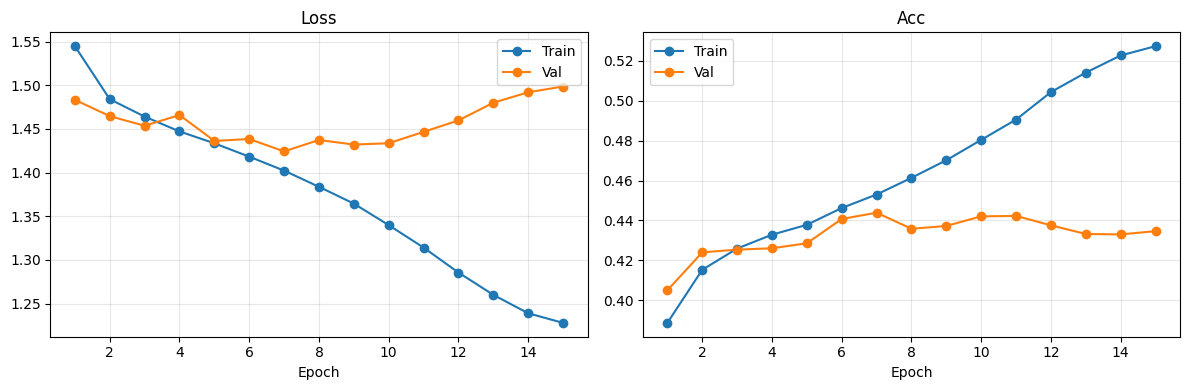

Saved: ./results/training_curves.png


In [ ]:
def plot_training_curves(history, save_dir):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, metric in zip(axes, ["loss", "acc"]):
        ax.plot(epochs, history[f"train_{metric}"], marker="o", label="Train")
        ax.plot(epochs, history[f"val_{metric}"],   marker="o", label="Val")
        ax.set_title(metric.capitalize())
        ax.set_xlabel("Epoch")
        ax.legend()
        ax.grid(alpha=0.3)
    plt.tight_layout()
    p = os.path.join(save_dir, "training_curves.png")
    plt.savefig(p, dpi=150); plt.show(); print(f"Saved: {p}")

plot_training_curves(history, config["results_dir"])

## 7. Baseline Inference on Test Set

In [ ]:
@torch.no_grad()
def run_inference(model, loader, device, desc="test"):
    """Collect logits, probs, preds, labels over a dataloader."""
    model.eval()
    all_logits, all_labels = [], []
    for images, labels in tqdm(loader, leave=False, desc=desc):
        all_logits.append(model(images.to(device)).cpu())
        lbl = labels.squeeze().long() if labels.dim() > 1 else labels
        all_labels.append(lbl.cpu())
    logits = torch.cat(all_logits)
    labels = torch.cat(all_labels)
    probs  = torch.softmax(logits, dim=1)
    preds  = logits.argmax(dim=1)
    return {
        "logits": logits.numpy(),
        "probs":  probs.numpy(),
        "preds":  preds.numpy(),
        "labels": labels.numpy(),
    }


# Load best checkpoint
model.load_state_dict(torch.load(ckpt_path, map_location=config["device"]))

res = run_inference(model, test_loader, config["device"])

test_acc = accuracy_score(res["labels"], res["preds"])
bal_acc  = balanced_accuracy_score(res["labels"], res["preds"])
print(f"Test acc: {test_acc:.4f}  |  Balanced acc: {bal_acc:.4f}")
print(f"\nClassification Report:")
print(classification_report(res["labels"], res["preds"], target_names=CLASS_NAMES, digits=4))

np.savez(os.path.join(config["results_dir"], "test_results.npz"), **res)

test:   0%|          | 0/7 [00:00<?, ?it/s]

Test acc: 0.5743  |  Balanced acc: 0.4896

Classification Report:
                  precision    recall  f1-score   support

      No Finding     0.8000    0.8108    0.8054        74
     Atelectasis     0.2632    0.3846    0.3125        13
    Cardiomegaly     0.3333    0.3333    0.3333        21
   Consolidation     0.4091    0.2812    0.3333        32
           Edema     0.4444    0.5517    0.4923        29
Pleural Effusion     0.6552    0.5758    0.6129        33

        accuracy                         0.5743       202
       macro avg     0.4842    0.4896    0.4816       202
    weighted avg     0.5803    0.5743    0.5734       202



## 8. Basic Confidence Scores and Selective Metrics

In [ ]:
# ----- Confidence scoring functions -----
# Each takes probs (N, C) or logits (N, C) and returns a (N,) score.
# Higher = more confident = more likely to be selected.

def score_msp(probs, logits=None):
    """Maximum softmax probability — Hendrycks & Gimpel 2016."""
    return probs.max(axis=1)


def score_margin(probs, logits=None):
    """Top-1 minus Top-2 probability margin."""
    s = np.sort(probs, axis=1)[:, ::-1]
    return s[:, 0] - s[:, 1]


def score_entropy(probs, logits=None):
    """Negative entropy (higher = more confident)."""
    eps = 1e-8
    return (probs * np.log(probs + eps)).sum(axis=1)  # negative of entropy


# ----- Selective metrics -----

def selective_metrics(preds, labels, scores, coverages=None):
    """Risk and accuracy at each coverage level.
    Samples sorted by descending confidence; top-k are 'selected'.
    """
    if coverages is None:
        coverages = np.linspace(0.05, 1.0, 40)
    n       = len(preds)
    correct = (preds == labels)
    order   = np.argsort(-scores)  # most confident first

    covs, risks, accs = [], [], []
    for c in coverages:
        k   = max(1, int(c * n))
        sel = order[:k]
        acc = correct[sel].mean()
        covs.append(k / n)
        risks.append(1.0 - acc)
        accs.append(acc)
    return {"coverage": np.array(covs), "risk": np.array(risks), "accuracy": np.array(accs)}


def aurc(metrics):
    return float(np.trapz(metrics["risk"], metrics["coverage"]))


def e_aurc(metrics, base_risk):
    return aurc(metrics) - base_risk


# Run basic scorers on test set
probs  = res["probs"]
logits = res["logits"]
preds  = res["preds"]
labels = res["labels"]

base_risk = 1.0 - test_acc

basic_scorers = {
    "MSP":    score_msp(probs),
    "Margin": score_margin(probs),
    "Entropy": score_entropy(probs),
}

basic_sc = {name: selective_metrics(preds, labels, s) for name, s in basic_scorers.items()}

for name, m in basic_sc.items():
    print(f"{name:<12} AURC={aurc(m):.5f}  eAURC={e_aurc(m, base_risk):.5f}")

MSP          AURC=0.26731  eAURC=-0.15843
Margin       AURC=0.27547  eAURC=-0.15027
Entropy      AURC=0.27182  eAURC=-0.15393


/tmp/ipykernel_12833/1647068806.py:46: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(metrics["risk"], metrics["coverage"]))


## 9. Basic Report Plots (Confusion Matrix, Confidence Histogram, ECE)

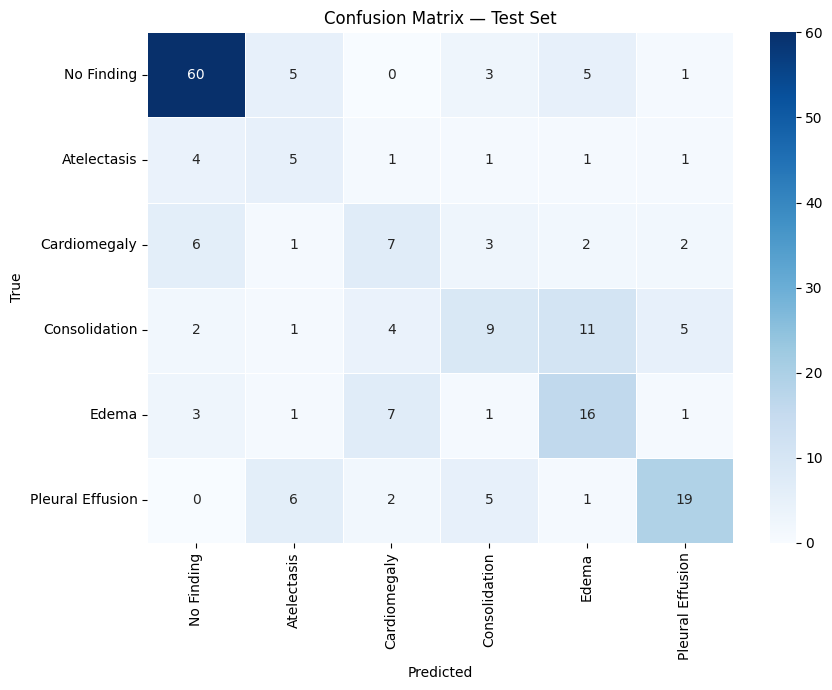

Saved: ./results/confusion_matrix.png


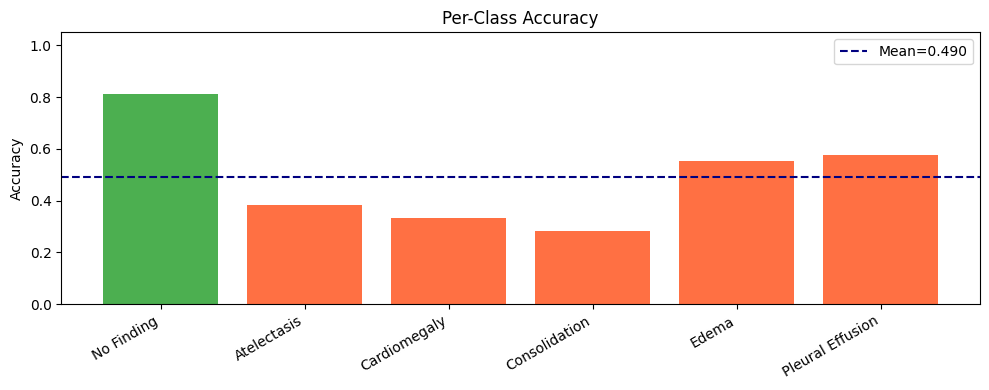

Saved: ./results/per_class_accuracy.png


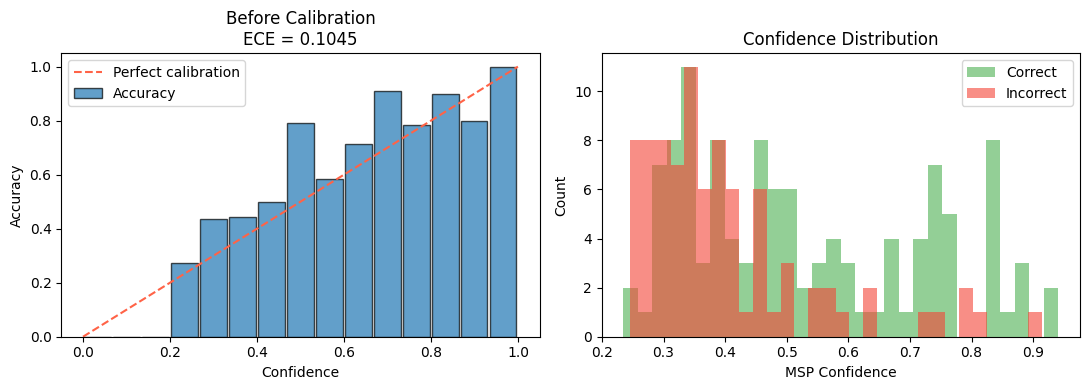

In [ ]:
def plot_confusion(y_true, y_pred, class_names, save_dir):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(9, 7))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names, linewidths=0.5)
    plt.title("Confusion Matrix — Test Set")
    plt.xlabel("Predicted"); plt.ylabel("True")
    plt.tight_layout()
    p = os.path.join(save_dir, "confusion_matrix.png")
    plt.savefig(p, dpi=150); plt.show(); print(f"Saved: {p}")


def plot_class_accuracy(y_true, y_pred, class_names, save_dir):
    cm  = confusion_matrix(y_true, y_pred)
    acc = cm.diagonal() / np.maximum(cm.sum(axis=1), 1)
    fig, ax = plt.subplots(figsize=(10, 4))
    bars = ax.bar(class_names, acc, color=["#4CAF50" if a >= 0.8 else "#FF7043" for a in acc])
    ax.axhline(acc.mean(), color="navy", linestyle="--", label=f"Mean={acc.mean():.3f}")
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Accuracy")
    ax.set_title("Per-Class Accuracy")
    ax.legend()
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    p = os.path.join(save_dir, "per_class_accuracy.png")
    plt.savefig(p, dpi=150); plt.show(); print(f"Saved: {p}")
    return acc


def compute_ece(probs, y_true, n_bins=15):
    conf = probs.max(axis=1)
    pred = probs.argmax(axis=1)
    cor  = (pred == y_true).astype(float)
    bins = np.linspace(0, 1, n_bins + 1)
    ece, bin_accs, bin_confs, bin_counts = 0.0, [], [], []
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (conf > lo) & (conf <= hi)
        if mask.sum() == 0:
            bin_accs.append(0.); bin_confs.append((lo+hi)/2); bin_counts.append(0)
            continue
        a = cor[mask].mean(); c = conf[mask].mean()
        ece += abs(a - c) * mask.mean()
        bin_accs.append(a); bin_confs.append(c); bin_counts.append(mask.sum())
    return ece, np.array(bin_accs), np.array(bin_confs), np.array(bin_counts), bins


def plot_reliability(probs, y_true, title="Reliability Diagram", save_path=None):
    ece, bin_accs, bin_confs, bin_counts, bins = compute_ece(probs, y_true)
    centers = 0.5 * (bins[:-1] + bins[1:])
    w       = bins[1] - bins[0]
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    # Reliability diagram
    axes[0].bar(centers, bin_accs, width=w*0.9, alpha=0.7, edgecolor="k", label="Accuracy")
    axes[0].plot([0,1],[0,1], "--", color="tomato", label="Perfect calibration")
    axes[0].set_xlabel("Confidence"); axes[0].set_ylabel("Accuracy")
    axes[0].set_title(f"{title}\nECE = {ece:.4f}")
    axes[0].legend()

    # Confidence histogram
    conf = probs.max(axis=1)
    cor  = (probs.argmax(axis=1) == y_true)
    axes[1].hist(conf[cor],  bins=30, alpha=0.6, label="Correct",   color="#4CAF50")
    axes[1].hist(conf[~cor], bins=30, alpha=0.6, label="Incorrect", color="#F44336")
    axes[1].set_xlabel("MSP Confidence"); axes[1].set_ylabel("Count")
    axes[1].set_title("Confidence Distribution")
    axes[1].legend()

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()
    return ece


plot_confusion(labels, preds, CLASS_NAMES, config["results_dir"])
per_class_acc = plot_class_accuracy(labels, preds, CLASS_NAMES, config["results_dir"])
baseline_ece  = plot_reliability(
    probs, labels, title="Before Calibration",
    save_path=os.path.join(config["results_dir"], "reliability_baseline.png")
)

## 10. Temperature Scaling
Post-hoc calibration: learn a single scalar T on the validation set.No model retraining required. Improves ECE substantially.

collecting val logits:   0%|          | 0/597 [00:00<?, ?it/s]

Optimal temperature T = 1.0631


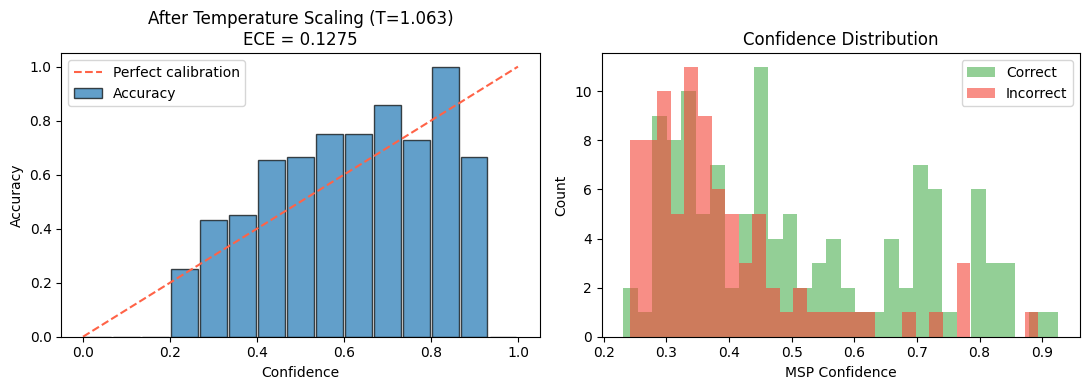


ECE before calibration: 0.1045
ECE after  calibration: 0.1275
Improvement:            -0.0230


In [ ]:
class TemperatureScaler(nn.Module):
    """Wraps a model and adds a learnable temperature parameter."""
    def __init__(self, model):
        super().__init__()
        self.model = model
        self.temperature = nn.Parameter(torch.ones(1) * 1.5)

    def forward(self, x):
        return self.model(x) / self.temperature

    def scale_logits(self, logits):
        return logits / self.temperature.item()


def fit_temperature(model, val_loader, device, lr=0.01, max_iter=200):
    """Optimize T to minimize NLL on val set. Returns fitted TemperatureScaler."""
    model.eval()
    all_logits, all_labels = [], []
    with torch.no_grad():
        for images, lbls in tqdm(val_loader, leave=False, desc="collecting val logits"):
            all_logits.append(model(images.to(device)).cpu())
            all_labels.append((lbls.squeeze() if lbls.dim() > 1 else lbls).cpu())
    val_logits = torch.cat(all_logits)
    val_labels = torch.cat(all_labels)

    scaler = TemperatureScaler(model).to(device)
    optimizer = optim.LBFGS([scaler.temperature], lr=lr, max_iter=max_iter)
    criterion = nn.CrossEntropyLoss()

    val_logits_dev = val_logits.to(device)
    val_labels_dev = val_labels.to(device)

    def closure():
        optimizer.zero_grad()
        scaled = val_logits_dev / scaler.temperature
        loss   = criterion(scaled, val_labels_dev)
        loss.backward()
        return loss

    optimizer.step(closure)

    T = scaler.temperature.item()
    print(f"Optimal temperature T = {T:.4f}")
    return scaler, T


temp_scaler, T_opt = fit_temperature(model, val_loader, config["device"],
                                      lr=config["temp_lr"], max_iter=config["temp_epochs"])

# Apply temperature to test logits
logits_scaled = logits / T_opt
probs_scaled  = torch.softmax(torch.tensor(logits_scaled), dim=1).numpy()

ece_after = plot_reliability(
    probs_scaled, labels, title=f"After Temperature Scaling (T={T_opt:.3f})",
    save_path=os.path.join(config["results_dir"], "reliability_calibrated.png")
)

print(f"\nECE before calibration: {baseline_ece:.4f}")
print(f"ECE after  calibration: {ece_after:.4f}")
print(f"Improvement:            {baseline_ece - ece_after:.4f}")

## 11. Advanced Confidence Scores
Implementing: Energy score, ODIN (temperature-only), Doctor score, and RLconf-K(the margin-family score from Liang et al. 2024).

In [ ]:
# ---- Energy Score (Liu et al. 2020) ----
def score_energy(probs, logits, T=1.0):
    max_logit = logits.max(axis=1, keepdims=True)
    energy = -T * (max_logit.squeeze(1) + np.log(np.exp((logits - max_logit) / T).sum(axis=1)))
    return -energy


# ---- ODIN — temperature scaling only (Liang et al. 2018) ----
def score_odin_temp(probs, logits, T=1000.0):
    shifted = logits - logits.max(axis=1, keepdims=True)
    probs_T = np.exp(shifted / T) / np.exp(shifted / T).sum(axis=1, keepdims=True)
    return probs_T.max(axis=1)


# ---- Full ODIN with input perturbation (Liang et al. 2018) ----
def score_odin_full(model, loader, device, T=1000.0, epsilon=0.0014):
    """Full ODIN: temperature scaling + input perturbation."""
    model.eval()
    all_scores = []
    for images, _ in loader:
        images = images.to(device)
        images.requires_grad_(True)
        logits = model(images)
        scaled = logits / T
        probs_T = torch.softmax(scaled, dim=1)
        max_probs, _ = probs_T.max(dim=1)
        loss = max_probs.sum()
        loss.backward()
        grad_sign = images.grad.data.sign()
        perturbed = images - epsilon * grad_sign
        with torch.no_grad():
            logits_pert = model(perturbed)
            scaled_pert = logits_pert / T
            probs_pert  = torch.softmax(scaled_pert, dim=1)
            scores_batch = probs_pert.max(dim=1).values.cpu().numpy()
        all_scores.append(scores_batch)
        images.requires_grad_(False)
    return np.concatenate(all_scores, axis=0)


# ---- Doctor Score ----
def score_doctor(probs, logits=None):
    p_hat  = probs.max(axis=1)
    p_sq   = (probs ** 2).sum(axis=1)
    doctor = 1.0 - p_hat ** 2 / (p_sq + 1e-8)
    return -doctor


# ---- RLconf-K (Liang et al. 2024) ----
def score_rlconf_k(probs, logits, K=2):
    sorted_logits = np.sort(logits, axis=1)[:, ::-1]
    top1 = sorted_logits[:, 0]
    topK = sorted_logits[:, min(K - 1, sorted_logits.shape[1] - 1)]
    return top1 - topK


# ---- RLgeo-M: geometric-mean variant (Liang et al. 2024) ----
def score_rlgeo_m(probs, logits, M=3):
    sorted_logits = np.sort(logits, axis=1)[:, ::-1]
    M_actual = min(M, sorted_logits.shape[1] - 1)
    top1 = sorted_logits[:, 0:1]
    gaps = top1 - sorted_logits[:, 1:M_actual+1]
    gaps = np.clip(gaps, 1e-8, None)
    return np.exp(np.log(gaps).mean(axis=1))


# ---- Collect all scorers ----
advanced_scorers = {
    "MSP":          score_msp(probs),
    "MSP-T (cal.)": score_odin_temp(probs, logits, T=T_opt),
    "Margin":       score_margin(probs),
    "Entropy":      score_entropy(probs),
    "Energy":       score_energy(probs, logits),
    "ODIN (T=1k)": score_odin_temp(probs, logits, T=1000.0),
    "Doctor":       score_doctor(probs),
    "RLconf-2":     score_rlconf_k(probs, logits, K=2),
    "RLconf-5":     score_rlconf_k(probs, logits, K=5),
    "RLgeo-3":      score_rlgeo_m(probs, logits, M=3),
}

sc_all = {name: selective_metrics(preds, labels, s) for name, s in advanced_scorers.items()}

print(f"{'Scorer':<18} {'AURC':>8} {'eAURC':>8}")
print("-" * 36)
for name, m in sc_all.items():
    print(f"{name:<18} {aurc(m):>8.5f} {e_aurc(m, base_risk):>8.5f}")

Scorer                 AURC    eAURC
------------------------------------
MSP                 0.26731 -0.15843
MSP-T (cal.)        0.26822 -0.15752
Margin              0.27547 -0.15027
Entropy             0.27182 -0.15393
Energy              0.29218 -0.13356
ODIN (T=1k)         0.26973 -0.15601
Doctor              0.27076 -0.15498
RLconf-2            0.28099 -0.14475
RLconf-5            0.29398 -0.13176
RLgeo-3             0.27521 -0.15053


/tmp/ipykernel_12833/1647068806.py:46: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(metrics["risk"], metrics["coverage"]))


/tmp/ipykernel_12833/1647068806.py:46: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(metrics["risk"], metrics["coverage"]))


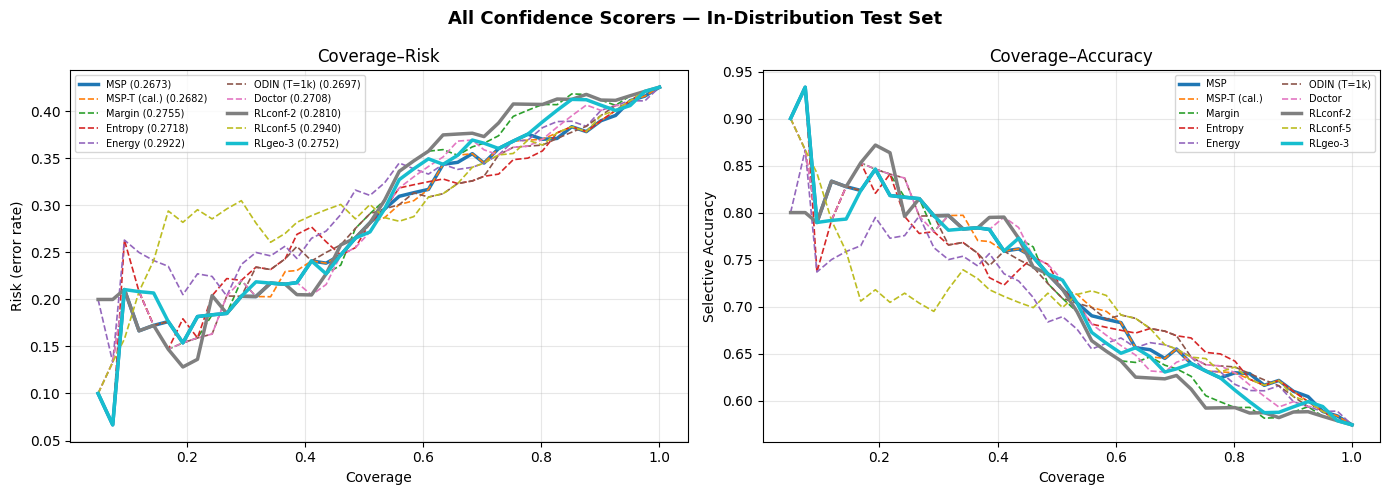

Saved: ./results/coverage_risk_all_scorers.png


In [ ]:
def plot_coverage_risk_multi(sc_dict, title, save_path, highlight=None):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    cmap = plt.colormaps.get_cmap("tab10").resampled(len(sc_dict))

    for i, (name, m) in enumerate(sc_dict.items()):
        a = aurc(m)
        lw  = 2.5 if (highlight and name in highlight) else 1.2
        ls  = "-"  if (highlight and name in highlight) else "--"
        col = cmap(i)
        axes[0].plot(m["coverage"], m["risk"],     color=col, lw=lw, ls=ls, label=f"{name} ({a:.4f})")
        axes[1].plot(m["coverage"], m["accuracy"], color=col, lw=lw, ls=ls, label=name)

    for ax, ylabel, ytitle in zip(axes, ["Risk (error rate)", "Selective Accuracy"],
                                         ["Coverage–Risk", "Coverage–Accuracy"]):
        ax.set_xlabel("Coverage")
        ax.set_ylabel(ylabel)
        ax.set_title(ytitle)
        ax.legend(fontsize=7, ncol=2)
        ax.grid(alpha=0.3)

    plt.suptitle(title, fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(save_path, dpi=150); plt.show()
    print(f"Saved: {save_path}")


plot_coverage_risk_multi(
    sc_all,
    title="All Confidence Scorers — In-Distribution Test Set",
    save_path=os.path.join(config["results_dir"], "coverage_risk_all_scorers.png"),
    highlight=["RLconf-2", "RLgeo-3", "MSP"]
)

## 12. MC Dropout Uncertainty
Run T stochastic forward passes with dropout active. Use variance / entropy ofpredictive distribution as uncertainty estimate.

In [ ]:
def mc_dropout_inference(model, loader, device, n_samples=30):
    """Run n_samples stochastic forward passes. Dropout stays ON (train mode)."""
    model.train()
    all_probs_list = []
    all_labels     = []

    with torch.no_grad():
        for i in range(n_samples):
            batch_probs = []
            for images, labels in loader:
                logits = model(images.to(device))
                batch_probs.append(torch.softmax(logits, dim=1).cpu().numpy())
                if i == 0:
                    all_labels.append((labels.squeeze() if labels.dim() > 1 else labels).numpy())
            all_probs_list.append(np.concatenate(batch_probs, axis=0))

    model.eval()

    all_probs  = np.stack(all_probs_list, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)

    mean_probs = all_probs.mean(axis=0)
    var_probs  = all_probs.var(axis=0)

    mc_msp      = mean_probs.max(axis=1)
    mc_entropy  = -(mean_probs * np.log(mean_probs + 1e-8)).sum(1)
    mc_var_mean = var_probs.mean(axis=1)

    preds_mc = mean_probs.argmax(axis=1)

    return {
        "mean_probs":  mean_probs,
        "var_probs":   var_probs,
        "preds":       preds_mc,
        "labels":      all_labels,
        "mc_msp":      mc_msp,
        "mc_entropy":  mc_entropy,
        "mc_var_mean": mc_var_mean,
    }


print(f"Running {config['mc_samples']} MC Dropout passes ...")
mc_res = mc_dropout_inference(model, test_loader, config["device"],
                               n_samples=config["mc_samples"])

mc_acc = accuracy_score(mc_res["labels"], mc_res["preds"])
print(f"MC Dropout test accuracy: {mc_acc:.4f}")

mc_preds  = mc_res["preds"]
mc_labels = mc_res["labels"]

mc_scorers = {
    "MC-MSP":      mc_res["mc_msp"],
    "MC-Entropy":  -mc_res["mc_entropy"],
    "MC-Variance": -mc_res["mc_var_mean"],
}

sc_mc = {name: selective_metrics(mc_preds, mc_labels, s) for name, s in mc_scorers.items()}

mc_base_risk = 1.0 - mc_acc
print(f"\n{'MC Scorer':<18} {'AURC':>8} {'eAURC':>8}")
print("-" * 36)
for name, m in sc_mc.items():
    print(f"{name:<18} {aurc(m):>8.5f} {e_aurc(m, mc_base_risk):>8.5f}")

Running 30 MC Dropout passes ...
MC Dropout test accuracy: 0.5000

MC Scorer              AURC    eAURC
------------------------------------
MC-MSP              0.34223 -0.15777
MC-Entropy          0.36743 -0.13257
MC-Variance         0.54419  0.04419


/tmp/ipykernel_12833/1647068806.py:46: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(metrics["risk"], metrics["coverage"]))


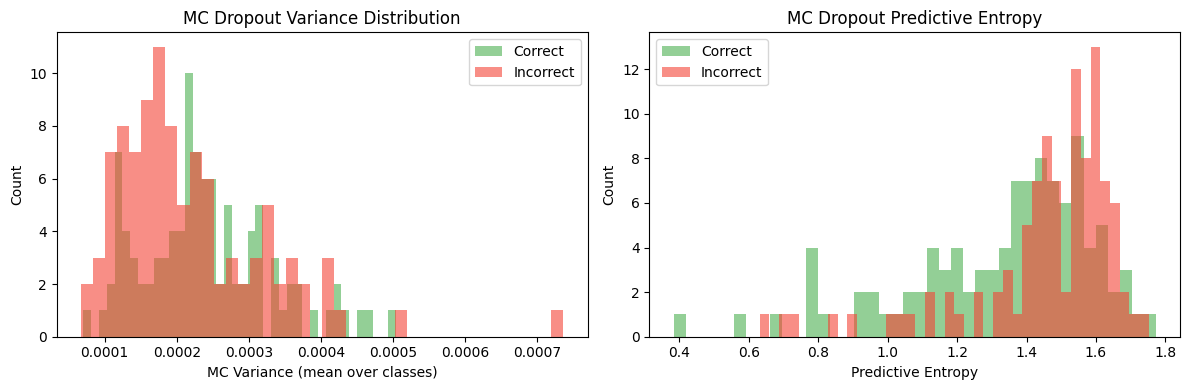

Saved: ./results/mc_dropout_uncertainty.png


In [ ]:
# Visualize MC Dropout uncertainty
correct_mask = (mc_preds == mc_labels)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(mc_res["mc_var_mean"][correct_mask],  bins=40, alpha=0.6, label="Correct",   color="#4CAF50")
axes[0].hist(mc_res["mc_var_mean"][~correct_mask], bins=40, alpha=0.6, label="Incorrect", color="#F44336")
axes[0].set_xlabel("MC Variance (mean over classes)")
axes[0].set_ylabel("Count")
axes[0].set_title("MC Dropout Variance Distribution")
axes[0].legend()

axes[1].hist(mc_res["mc_entropy"][correct_mask],  bins=40, alpha=0.6, label="Correct",   color="#4CAF50")
axes[1].hist(mc_res["mc_entropy"][~correct_mask], bins=40, alpha=0.6, label="Incorrect", color="#F44336")
axes[1].set_xlabel("Predictive Entropy")
axes[1].set_ylabel("Count")
axes[1].set_title("MC Dropout Predictive Entropy")
axes[1].legend()

plt.tight_layout()
p = os.path.join(config["results_dir"], "mc_dropout_uncertainty.png")
plt.savefig(p, dpi=150); plt.show(); print(f"Saved: {p}")

## 13. Covariate Shift Simulation — Type C Errors
Simulate scanner/acquisition domain shift by applying corruptions to the test set.This mimics what happens when a model trained at one hospital sees data from another.We test three corruptions at increasing severity.

In [ ]:
class CorruptedDataset(torch.utils.data.Dataset):
    """Wraps an existing dataset and applies a corruption transform on top."""
    def __init__(self, base_dataset, corruption_fn):
        self.base = base_dataset
        self.corrupt = corruption_fn

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        image, label = self.base[idx]
        return self.corrupt(image), label


def make_corruption(kind, severity):
    """Return a tensor→tensor corruption function."""
    if kind == "gaussian_noise":
        def fn(x): return torch.clamp(x + torch.randn_like(x) * severity, -3, 3)
    elif kind == "gaussian_blur":
        k = int(severity * 10) | 1
        blur = transforms.GaussianBlur(kernel_size=max(3, k), sigma=severity)
        def fn(x): return blur(x)
    elif kind == "brightness":
        def fn(x): return torch.clamp(x + severity, -3, 3)
    elif kind == "contrast":
        def fn(x): return torch.clamp(x * (1 + severity), -3, 3)
    else:
        raise ValueError(kind)
    return fn


clean_test_ds = test_loader.dataset

CORRUPTIONS = {
    "Clean":            None,
    "Noise (mild)":     make_corruption("gaussian_noise", 0.1),
    "Noise (severe)":   make_corruption("gaussian_noise", 0.4),
    "Blur (mild)":      make_corruption("gaussian_blur",  0.5),
    "Blur (severe)":    make_corruption("gaussian_blur",  2.0),
    "Brightness (mild)": make_corruption("brightness",   0.3),
    "Brightness (sev.)": make_corruption("brightness",   1.0),
    "Contrast (mild)":   make_corruption("contrast",     0.5),
    "Contrast (sev.)": make_corruption("contrast",       2.0),
}

def make_loader(ds, config):
    return DataLoader(ds, batch_size=config["batch_size"], shuffle=False,
                      num_workers=config["num_workers"], pin_memory=torch.cuda.is_available())


corrupt_loaders = {}
for name, fn in CORRUPTIONS.items():
    if fn is None:
        corrupt_loaders[name] = test_loader
    else:
        corrupt_loaders[name] = make_loader(CorruptedDataset(clean_test_ds, fn), config)

print(f"Built {len(corrupt_loaders)} corrupted test loaders.")

Built 9 corrupted test loaders.


In [ ]:
# Run inference on each corruption
corrupt_results = {}
for name, loader in corrupt_loaders.items():
    r = run_inference(model, loader, config["device"], desc=name[:15])
    acc = accuracy_score(r["labels"], r["preds"])
    corrupt_results[name] = {"res": r, "acc": acc}
    print(f"{name:<25} acc={acc:.4f}")

# AURC for MSP and RLconf-2 on each corrupted set
print(f"\n{'Corruption':<25} {'Acc':>6} {'AURC-MSP':>10} {'AURC-RLconf2':>13}")
print("-" * 56)
for name, data in corrupt_results.items():
    r = data["res"]
    s_msp = score_msp(r["probs"])
    s_rl2 = score_rlconf_k(r["probs"], r["logits"], K=2)
    m_msp = selective_metrics(r["preds"], r["labels"], s_msp)
    m_rl2 = selective_metrics(r["preds"], r["labels"], s_rl2)
    print(f"{name:<25} {data['acc']:>6.4f} {aurc(m_msp):>10.5f} {aurc(m_rl2):>13.5f}")

Clean:   0%|          | 0/7 [00:00<?, ?it/s]

Clean                     acc=0.5446


Noise (mild):   0%|          | 0/7 [00:00<?, ?it/s]

Noise (mild)              acc=0.4505


Noise (severe):   0%|          | 0/7 [00:00<?, ?it/s]

...

Contrast (mild):   0%|          | 0/7 [00:00<?, ?it/s]

Contrast (mild)           acc=0.5396


Contrast (sev.):   0%|          | 0/7 [00:00<?, ?it/s]

Contrast (sev.)           acc=0.4950

Corruption                   Acc   AURC-MSP  AURC-RLconf2
--------------------------------------------------------
Clean                     0.5446    0.30511       0.31415
Noise (mild)              0.4505    0.35321       0.36309
Noise (severe)            0.1238    0.83116       0.82102
Blur (mild)               0.5594    0.29393       0.29899
Blur (severe)             0.4257    0.33966       0.34710
Brightness (mild)         0.5495    0.29169       0.30618
Brightness (sev.)         0.5495    0.28016       0.28861
Contrast (mild)           0.5396    0.31896       0.31778
Contrast (sev.)           0.4950    0.34402       0.33207


/tmp/ipykernel_12833/1647068806.py:46: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(metrics["risk"], metrics["coverage"]))


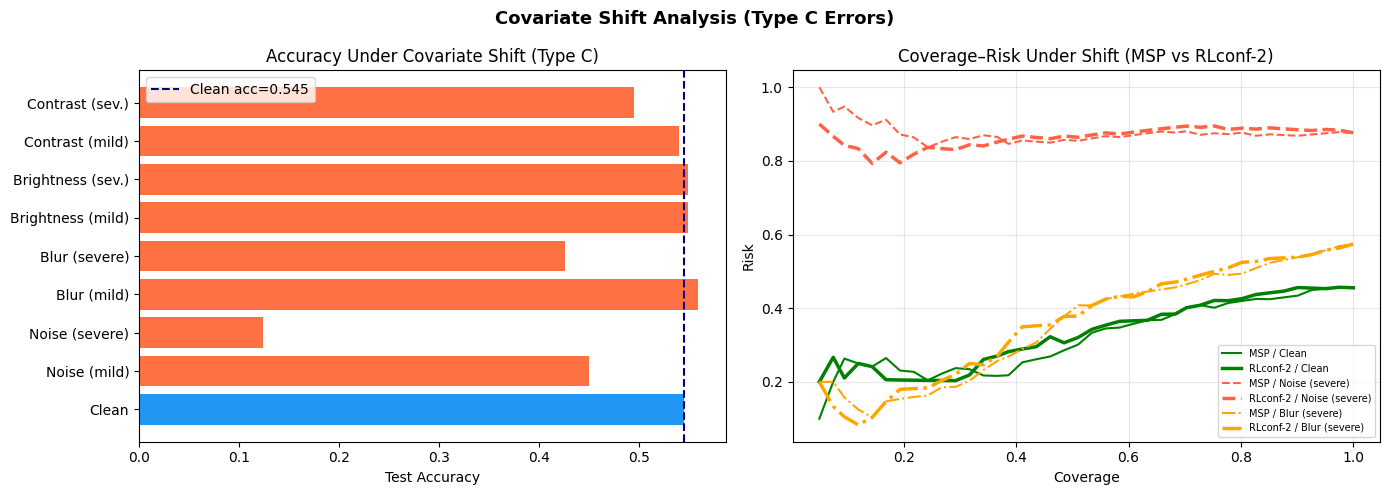

Saved: ./results/covariate_shift_analysis.png


In [ ]:
# Accuracy degradation under covariate shift
names = list(corrupt_results.keys())
accs  = [corrupt_results[n]["acc"] for n in names]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of accuracy drop
colors = ["#2196F3" if n == "Clean" else "#FF7043" for n in names]
axes[0].barh(names, accs, color=colors)
axes[0].axvline(corrupt_results["Clean"]["acc"], color="navy", linestyle="--",
                label=f"Clean acc={corrupt_results['Clean']['acc']:.3f}")
axes[0].set_xlabel("Test Accuracy")
axes[0].set_title("Accuracy Under Covariate Shift (Type C)")
axes[0].legend()

# Coverage-risk for MSP vs RLconf-2 on clean vs most severe noise
for cname, color, ls in [("Clean", "green", "-"),
                          ("Noise (severe)", "tomato", "--"),
                          ("Blur (severe)", "orange", "-.")]:
    r = corrupt_results[cname]["res"]
    for scorer_name, scorer_fn, lw in [("MSP", score_msp, 1.5),
                                        ("RLconf-2", lambda p,l: score_rlconf_k(p,l,K=2), 2.5)]:
        s  = scorer_fn(r["probs"], r["logits"]) if scorer_name != "MSP" else scorer_fn(r["probs"])
        m  = selective_metrics(r["preds"], r["labels"], s)
        axes[1].plot(m["coverage"], m["risk"], color=color, lw=lw, ls=ls,
                     label=f"{scorer_name} / {cname}")

axes[1].set_xlabel("Coverage")
axes[1].set_ylabel("Risk")
axes[1].set_title("Coverage–Risk Under Shift (MSP vs RLconf-2)")
axes[1].legend(fontsize=7)
axes[1].grid(alpha=0.3)

plt.suptitle("Covariate Shift Analysis (Type C Errors)", fontsize=13, fontweight="bold")
plt.tight_layout()
p = os.path.join(config["results_dir"], "covariate_shift_analysis.png")
plt.savefig(p, dpi=150); plt.show(); print(f"Saved: {p}")

## 14. Label Shift Simulation — Type B Errors
Simulate novel-class / label-shift scenarios (Type B from Liang et al. 2024):train on classes 0..K-1, then evaluate on all classes including the withheld ones.The model will be overconfident on novel classes — SC should reject them.For CheXpert, we hold out Consolidation (index 3) and Edema (index 4).

In [ ]:
holdout = set(config["holdout_classes"])
seen    = [c for c in range(config["num_classes"]) if c not in holdout]
n_seen  = len(seen)

# Build a mapping from original class indices to consecutive 0..n_seen-1
seen_to_new = {orig: new_idx for new_idx, orig in enumerate(seen)}

print(f"Seen classes: {[CLASS_NAMES[c] for c in seen]}")
print(f"Holdout (novel) classes: {[CLASS_NAMES[c] for c in sorted(holdout)]}")
print(f"Label mapping: {seen_to_new}")


class RemappedSubset(Dataset):
    """Wraps a dataset subset and remaps labels to consecutive 0..n_seen-1."""
    def __init__(self, base_dataset, indices, class_map):
        self.base = base_dataset
        self.indices = indices
        self.class_map = class_map

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        img, lbl = self.base[self.indices[idx]]
        lbl_int = int(lbl.item()) if torch.is_tensor(lbl) else int(lbl)
        new_lbl = self.class_map[lbl_int]
        return img, torch.tensor(new_lbl, dtype=torch.long)


def get_class_indices(dataset, keep_classes):
    """Return indices of samples belonging to keep_classes."""
    keep = set(keep_classes)
    indices = []
    for i in range(len(dataset)):
        _, lbl = dataset[i]
        lbl_int = int(lbl.item()) if torch.is_tensor(lbl) else int(lbl)
        if lbl_int in keep:
            indices.append(i)
    return indices


# Build datasets
train_ds_full = train_loader.dataset
test_ds_full  = test_loader.dataset

print("\nFinding seen-class training samples...")
seen_train_idx = get_class_indices(train_ds_full, seen)
seen_train_ds  = RemappedSubset(train_ds_full, seen_train_idx, seen_to_new)
ls_train_loader = make_loader(seen_train_ds, config)

ls_test_loader = make_loader(test_ds_full, config)

print(f"Label-shift train size: {len(seen_train_ds)} (seen classes only)")
print(f"Full test size:         {len(test_ds_full)} (all classes)")


Seen classes: ['No Finding', 'Atelectasis', 'Cardiomegaly', 'Pleural Effusion']
Holdout (novel) classes: ['Consolidation', 'Edema']
Label mapping: {0: 0, 1: 1, 2: 2, 5: 3}

Finding seen-class training samples...
Label-shift train size: 117355 (seen classes only)
Full test size:         202 (all classes)


In [ ]:
# Train a separate model on seen classes only
ls_config = dict(config)
ls_config["num_classes"] = n_seen
ls_config["epochs"]      = max(5, config["epochs"] // 2)

ls_model = build_model(ls_config)

ls_class_weights = compute_class_weights(ls_train_loader, n_seen)
ls_criterion = nn.CrossEntropyLoss(weight=ls_class_weights.to(config["device"]))
ls_optimizer = optim.Adam(ls_model.parameters(), lr=config["lr"], weight_decay=config["weight_decay"])
ls_scheduler = optim.lr_scheduler.CosineAnnealingLR(ls_optimizer, T_max=ls_config["epochs"])
ls_ckpt      = os.path.join(config["checkpoint_dir"], "ls_model.pt")

ls_best = 0.0
for epoch in range(1, ls_config["epochs"] + 1):
    tl, ta = train_one_epoch(ls_model, ls_train_loader, ls_criterion, ls_optimizer, config["device"])
    ls_scheduler.step()
    print(f"LS Ep {epoch:02d} | Train loss={tl:.4f} acc={ta:.4f}")
    if ta > ls_best:
        ls_best = ta
        torch.save(ls_model.state_dict(), ls_ckpt)

ls_model.load_state_dict(torch.load(ls_ckpt, map_location=config["device"]))
print(f"\nLabel-shift model trained. Best train acc: {ls_best:.4f}")

train:   0%|          | 0/3668 [00:00<?, ?it/s]

LS Ep 01 | Train loss=1.1303 acc=0.5219


train:   0%|          | 0/3668 [00:00<?, ?it/s]

LS Ep 02 | Train loss=1.0561 acc=0.5613


train:   0%|          | 0/3668 [00:00<?, ?it/s]

...

LS Ep 05 | Train loss=0.9694 acc=0.6014


train:   0%|          | 0/3668 [01:40<?, ?it/s]

LS Ep 06 | Train loss=0.9369 acc=0.6158


train:   0%|          | 0/3668 [00:00<?, ?it/s]

LS Ep 07 | Train loss=0.9134 acc=0.6267

Label-shift model trained. Best train acc: 0.6267


In [ ]:
@torch.no_grad()
def run_inference_with_novelty(model, loader, device, seen_classes):
    """Inference where we know which samples are 'novel' (unseen at train time)."""
    model.eval()
    seen_set = set(seen_classes)
    all_logits, all_labels, is_novel = [], [], []

    for images, labels in tqdm(loader, leave=False, desc="ls-inference"):
        logits = model(images.to(device)).cpu()
        lbls   = labels.squeeze() if labels.dim() > 1 else labels
        all_logits.append(logits)
        all_labels.append(lbls)
        is_novel.append(torch.tensor([int(l.item()) not in seen_set for l in lbls]))

    logits    = torch.cat(all_logits).numpy()
    labels_np = torch.cat(all_labels).numpy()
    is_novel  = torch.cat(is_novel).numpy().astype(bool)
    probs     = torch.softmax(torch.tensor(logits), dim=1).numpy()
    preds     = logits.argmax(axis=1)

    correct = np.zeros(len(preds), dtype=bool)
    for i, (p, l, novel) in enumerate(zip(preds, labels_np, is_novel)):
        if not novel and int(l) in seen_set:
            seen_idx = seen_classes.index(int(l))
            correct[i] = (p == seen_idx)

    return {
        "logits":   logits,
        "probs":    probs,
        "preds":    preds,
        "labels":   labels_np,
        "correct":  correct,
        "is_novel": is_novel,
    }


ls_res = run_inference_with_novelty(ls_model, ls_test_loader, config["device"], seen)

overall_err   = 1.0 - ls_res["correct"].mean()
seen_err      = 1.0 - ls_res["correct"][~ls_res["is_novel"]].mean()
novel_err     = 1.0

print(f"Label-shift model — test error rates:")
print(f"  Overall:      {overall_err:.4f}")
print(f"  Seen classes: {seen_err:.4f}")
print(f"  Novel classes (Type B): {novel_err:.4f} (always wrong by construction)")

ls-inference:   0%|          | 0/7 [00:00<?, ?it/s]

Label-shift model — test error rates:
  Overall:      0.5594
  Seen classes: 0.3688
  Novel classes (Type B): 1.0000 (always wrong by construction)


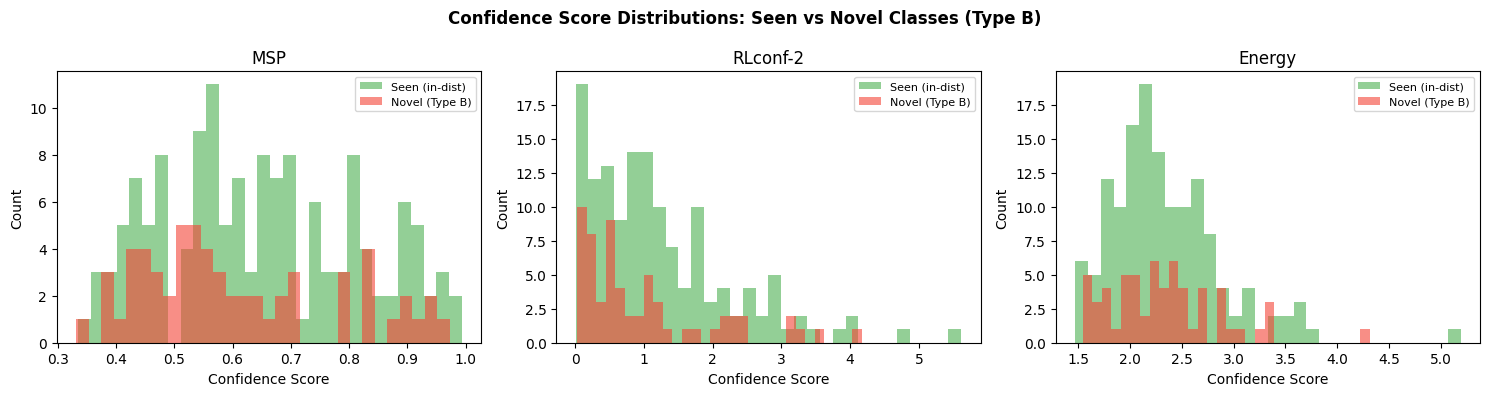

Saved: ./results/label_shift_confidence.png


In [ ]:
# How well do confidence scores detect the novel (Type B error) samples?
ls_probs  = ls_res["probs"]
ls_logits = ls_res["logits"]
is_novel  = ls_res["is_novel"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

scorer_pairs = [
    ("MSP",     score_msp(ls_probs)),
    ("RLconf-2", score_rlconf_k(ls_probs, ls_logits, K=2)),
    ("Energy",  score_energy(ls_probs, ls_logits)),
]

for ax, (sname, scores) in zip(axes, scorer_pairs):
    ax.hist(scores[~is_novel], bins=30, alpha=0.6, label="Seen (in-dist)",  color="#4CAF50")
    ax.hist(scores[is_novel],  bins=30, alpha=0.6, label="Novel (Type B)", color="#F44336")
    ax.set_xlabel("Confidence Score")
    ax.set_ylabel("Count")
    ax.set_title(f"{sname}")
    ax.legend(fontsize=8)

plt.suptitle("Confidence Score Distributions: Seen vs Novel Classes (Type B)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
p = os.path.join(config["results_dir"], "label_shift_confidence.png")
plt.savefig(p, dpi=150); plt.show(); print(f"Saved: {p}")

## 15. Type A / B / C Error Decomposition
Following Liang et al. (2024), we decompose errors into:- **Type A**: in-distribution errors (model wrong on standard test data)- **Type B**: label-shift errors (novel classes model has never seen)- **Type C**: covariate-shift errors (same classes, domain-shifted inputs)For CheXpert, Type A errors are particularly interesting because uncertain/ambiguouslabels (U-labels mapped via U-Ones) create inherent label noise that drivesin-distribution misclassification.

In [ ]:
# Type A: in-distribution errors on clean test
type_A_mask = (res["preds"] != res["labels"])

# Type B (simulated): novel-class errors from label-shift experiment
type_B_mask = ls_res["is_novel"]

# Type C (simulated): correct on clean, wrong under noise
noise_res = corrupt_results["Noise (severe)"]["res"]
type_C_mask = (~type_A_mask) & (noise_res["preds"] != noise_res["labels"])

n_total = len(res["labels"])
n_A = type_A_mask.sum()
n_C = type_C_mask.sum()
n_B = type_B_mask.sum()

print("Error type decomposition (original test set):")
print(f"  Correct:      {n_total - n_A} / {n_total} ({(1-n_A/n_total)*100:.1f}%)")
print(f"  Type A (ID):  {n_A}  ({n_A/n_total*100:.1f}% of all samples)")
print(f"  Type C (cov): {n_C}  ({n_C/n_total*100:.1f}% of all samples — corrupted only)")
print(f"  Type B (novel, separate LS exp): {n_B} / {len(ls_res['labels'])} ({n_B/len(ls_res['labels'])*100:.1f}%)")

Error type decomposition (original test set):
  Correct:      116 / 202 (57.4%)
  Type A (ID):  86  (42.6% of all samples)
  Type C (cov): 100  (49.5% of all samples — corrupted only)
  Type B (novel, separate LS exp): 61 / 202 (30.2%)


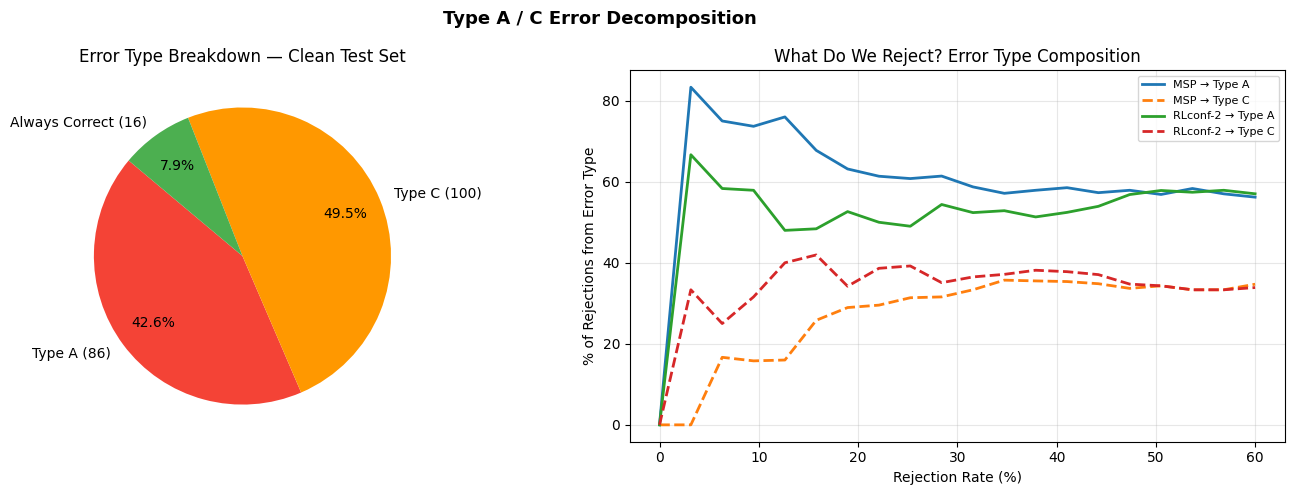

Saved: ./results/error_type_decomposition.png


In [ ]:
def rejection_error_type_analysis(preds, labels, type_A, type_C, scores, n_steps=20):
    n         = len(preds)
    correct   = (preds == labels)
    order     = np.argsort(scores)

    rejection_rates = np.linspace(0, 0.6, n_steps)
    frac_A, frac_C  = [], []

    for rr in rejection_rates:
        k        = int(rr * n)
        rejected = order[:k] if k > 0 else np.array([], dtype=int)
        if len(rejected) == 0:
            frac_A.append(0.0); frac_C.append(0.0)
            continue
        n_rej_A = type_A[rejected].sum()
        n_rej_C = type_C[rejected].sum()
        total_rej = max(1, len(rejected))
        frac_A.append(n_rej_A / total_rej)
        frac_C.append(n_rej_C / total_rej)

    return np.array(rejection_rates), np.array(frac_A), np.array(frac_C)


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

n_always_correct = n_total - n_A - n_C
sizes = [n_A, n_C, n_always_correct]
labels_pie = [f"Type A ({n_A})", f"Type C ({n_C})", f"Always Correct ({n_always_correct})"]
colors_pie = ["#F44336", "#FF9800", "#4CAF50"]
axes[0].pie(sizes, labels=labels_pie, colors=colors_pie, autopct="%1.1f%%",
            startangle=140, pctdistance=0.75)
axes[0].set_title("Error Type Breakdown — Clean Test Set")

for scorer_name, scores in [("MSP", score_msp(probs)),
                             ("RLconf-2", score_rlconf_k(probs, logits, K=2))]:
    rr, fA, fC = rejection_error_type_analysis(preds, labels, type_A_mask, type_C_mask, scores)
    axes[1].plot(rr * 100, fA * 100, label=f"{scorer_name} → Type A",  linewidth=2)
    axes[1].plot(rr * 100, fC * 100, label=f"{scorer_name} → Type C", linewidth=2, linestyle="--")

axes[1].set_xlabel("Rejection Rate (%)")
axes[1].set_ylabel("% of Rejections from Error Type")
axes[1].set_title("What Do We Reject? Error Type Composition")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.suptitle("Type A / C Error Decomposition", fontsize=13, fontweight="bold")
plt.tight_layout()
p = os.path.join(config["results_dir"], "error_type_decomposition.png")
plt.savefig(p, dpi=150); plt.show(); print(f"Saved: {p}")

## 16. Class-Weighted Selective Risk
Not all errors are equal in clinical settings. We assign severity weights to eachmisclassification and compute a weighted AURC. Missing a cardiomegaly or pleuraleffusion is worse than misclassifying "No Finding".

In [ ]:
# CheXpert severity weights
# Classes: 0=No Finding, 1=Atelectasis, 2=Cardiomegaly,
#          3=Consolidation, 4=Edema, 5=Pleural Effusion
#
# Clinical severity: Pleural Effusion and Cardiomegaly if missed can be
# life-threatening. Consolidation (pneumonia) is acute. Edema is urgent.
# Atelectasis is common and less acute. No Finding errors are least costly.

SEVERITY_WEIGHTS = {
    0: 1.0,   # No Finding — least severe to misclassify
    1: 2.5,   # Atelectasis — common, moderate severity
    2: 4.0,   # Cardiomegaly — important cardiac finding
    3: 4.5,   # Consolidation — acute pneumonia, high severity
    4: 4.0,   # Edema — pulmonary edema, high severity
    5: 5.0,   # Pleural Effusion — can be life-threatening
}

severity_arr = np.array([SEVERITY_WEIGHTS.get(c, 1.0) for c in range(config["num_classes"])])
print("Severity weights:", {CLASS_NAMES[i]: severity_arr[i] for i in range(config["num_classes"])})


def weighted_selective_risk(preds, labels, scores, weights, coverages=None):
    if coverages is None:
        coverages = np.linspace(0.05, 1.0, 40)
    n = len(preds)
    sample_costs = np.where(
        preds == labels,
        0.0,
        np.array([weights[int(l)] for l in labels])
    )
    order = np.argsort(-scores)
    covs, w_risks = [], []
    for c in coverages:
        k   = max(1, int(c * n))
        sel = order[:k]
        w_risk = sample_costs[sel].mean()
        covs.append(k / n)
        w_risks.append(w_risk)
    return {"coverage": np.array(covs), "weighted_risk": np.array(w_risks)}


def weighted_aurc(wm):
    return float(np.trapz(wm["weighted_risk"], wm["coverage"]))


print(f"\n{'Scorer':<18} {'AURC (uniform)':>16} {'WAURC (severity)':>18}")
print("-" * 54)

w_sc_results = {}
for name, scores in advanced_scorers.items():
    m_unif   = selective_metrics(preds, labels, scores)
    m_weight = weighted_selective_risk(preds, labels, scores, SEVERITY_WEIGHTS)
    w_sc_results[name] = {"uniform": m_unif, "weighted": m_weight}
    print(f"{name:<18} {aurc(m_unif):>16.5f} {weighted_aurc(m_weight):>18.5f}")

Severity weights: {'No Finding': np.float64(1.0), 'Atelectasis': np.float64(2.5), 'Cardiomegaly': np.float64(4.0), 'Consolidation': np.float64(4.5), 'Edema': np.float64(4.0), 'Pleural Effusion': np.float64(5.0)}

Scorer               AURC (uniform)   WAURC (severity)
------------------------------------------------------
MSP                         0.26731            0.95976
MSP-T (cal.)                0.26822            0.96358
Margin                      0.27547            1.00247
Entropy                     0.27182            0.97725
Energy                      0.29218            1.06841
ODIN (T=1k)                 0.26973            0.96409
Doctor                      0.27076            0.97900
RLconf-2                    0.28099            1.02568
RLconf-5                    0.29398            1.09032
RLgeo-3                     0.27521            0.99961


/tmp/ipykernel_12833/1647068806.py:46: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(metrics["risk"], metrics["coverage"]))
/tmp/ipykernel_12833/2875898784.py:43: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(wm["weighted_risk"], wm["coverage"]))


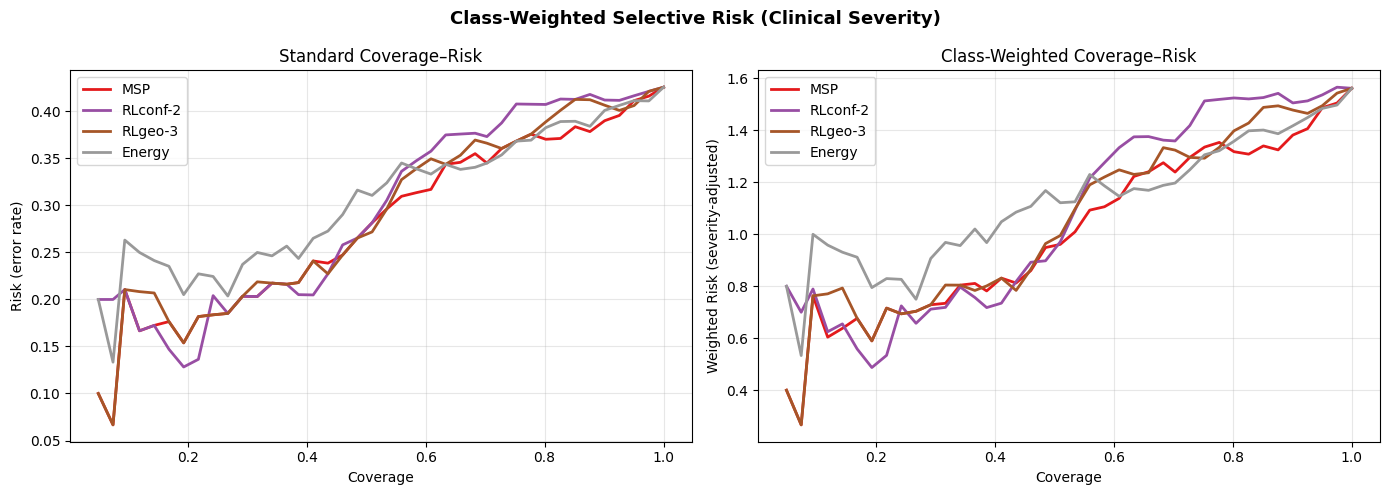

Saved: ./results/weighted_coverage_risk.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

highlight = ["MSP", "RLconf-2", "RLgeo-3", "Energy"]
cmap = plt.colormaps.get_cmap("Set1").resampled(len(highlight))

for i, name in enumerate(highlight):
    d = w_sc_results[name]
    c = cmap(i)
    axes[0].plot(d["uniform"]["coverage"],   d["uniform"]["risk"],      color=c, lw=2, label=name)
    axes[1].plot(d["weighted"]["coverage"],  d["weighted"]["weighted_risk"], color=c, lw=2, label=name)

for ax, ylabel, title in zip(axes,
    ["Risk (error rate)", "Weighted Risk (severity-adjusted)"],
    ["Standard Coverage–Risk", "Class-Weighted Coverage–Risk"]):
    ax.set_xlabel("Coverage")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle("Class-Weighted Selective Risk (Clinical Severity)", fontsize=13, fontweight="bold")
plt.tight_layout()
p = os.path.join(config["results_dir"], "weighted_coverage_risk.png")
plt.savefig(p, dpi=150); plt.show(); print(f"Saved: {p}")

## 17. Selective Calibration Analysis
Does selective prediction also improve calibration? We compute ECE on the *accepted*subset as a function of coverage.

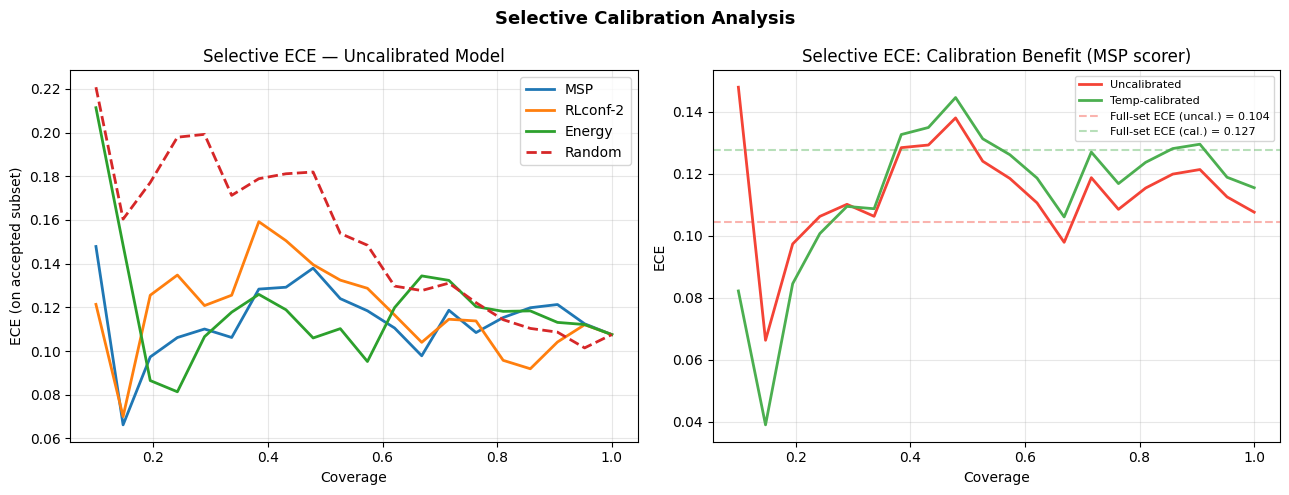

Saved: ./results/selective_calibration.png


In [ ]:
def ece_vs_coverage(probs, labels, scores, n_coverage_points=20, n_bins=10):
    n      = len(labels)
    order  = np.argsort(-scores)
    covs   = np.linspace(0.1, 1.0, n_coverage_points)
    eces   = []

    for c in covs:
        k        = max(n_bins, int(c * n))
        sel      = order[:k]
        ece, *_  = compute_ece(probs[sel], labels[sel], n_bins=n_bins)
        eces.append(ece)

    return covs, np.array(eces)


probs_cal = probs_scaled

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for name, scores in [("MSP", advanced_scorers["MSP"]),
                      ("RLconf-2", advanced_scorers["RLconf-2"]),
                      ("Energy", advanced_scorers["Energy"]),
                      ("Random", np.random.rand(len(preds)))]:
    covs, eces = ece_vs_coverage(probs, labels, scores)
    ls = "--" if name == "Random" else "-"
    axes[0].plot(covs, eces, label=name, lw=2, linestyle=ls)

axes[0].set_xlabel("Coverage")
axes[0].set_ylabel("ECE (on accepted subset)")
axes[0].set_title("Selective ECE — Uncalibrated Model")
axes[0].legend()
axes[0].grid(alpha=0.3)

msp_scores = advanced_scorers["MSP"]
covs_u, eces_u = ece_vs_coverage(probs,     labels, msp_scores)
covs_c, eces_c = ece_vs_coverage(probs_cal, labels, msp_scores)

axes[1].plot(covs_u, eces_u, lw=2, label="Uncalibrated",   color="#F44336")
axes[1].plot(covs_c, eces_c, lw=2, label="Temp-calibrated", color="#4CAF50")
axes[1].axhline(baseline_ece, linestyle="--", color="#F44336", alpha=0.4, label=f"Full-set ECE (uncal.) = {baseline_ece:.3f}")
axes[1].axhline(ece_after,    linestyle="--", color="#4CAF50", alpha=0.4, label=f"Full-set ECE (cal.) = {ece_after:.3f}")
axes[1].set_xlabel("Coverage")
axes[1].set_ylabel("ECE")
axes[1].set_title("Selective ECE: Calibration Benefit (MSP scorer)")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.suptitle("Selective Calibration Analysis", fontsize=13, fontweight="bold")
plt.tight_layout()
p = os.path.join(config["results_dir"], "selective_calibration.png")
plt.savefig(p, dpi=150); plt.show(); print(f"Saved: {p}")

## 18. Feature Space Visualization — t-SNE

In [ ]:
@torch.no_grad()
def extract_features(model, loader, device, max_samples=2000):
    model.eval()
    all_feats, all_labels = [], []
    total = 0

    for images, labels in tqdm(loader, leave=False, desc="features"):
        feats = model.get_features(images.to(device)).cpu()
        all_feats.append(feats)
        all_labels.append((labels.squeeze() if labels.dim() > 1 else labels))
        total += images.size(0)
        if total >= max_samples:
            break

    feats  = torch.cat(all_feats, dim=0)[:max_samples].numpy()
    labels = torch.cat(all_labels, dim=0)[:max_samples].numpy()
    return feats, labels


print("Extracting features ...")
feats, feat_labels = extract_features(model, test_loader, config["device"], max_samples=2000)

print(f"Running t-SNE on {len(feats)} samples × {feats.shape[1]} features ...")
tsne  = TSNE(n_components=2, perplexity=30, random_state=config["seed"], n_iter=1000)
emb   = tsne.fit_transform(feats)

feat_probs  = res["probs"][:len(feats)]
feat_preds  = res["preds"][:len(feats)]
feat_conf   = score_msp(feat_probs)
feat_correct = (feat_preds == feat_labels)
feat_labels_trunc = feat_labels

Extracting features ...


features:   0%|          | 0/7 [00:00<?, ?it/s]

Running t-SNE on 202 samples × 512 features ...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


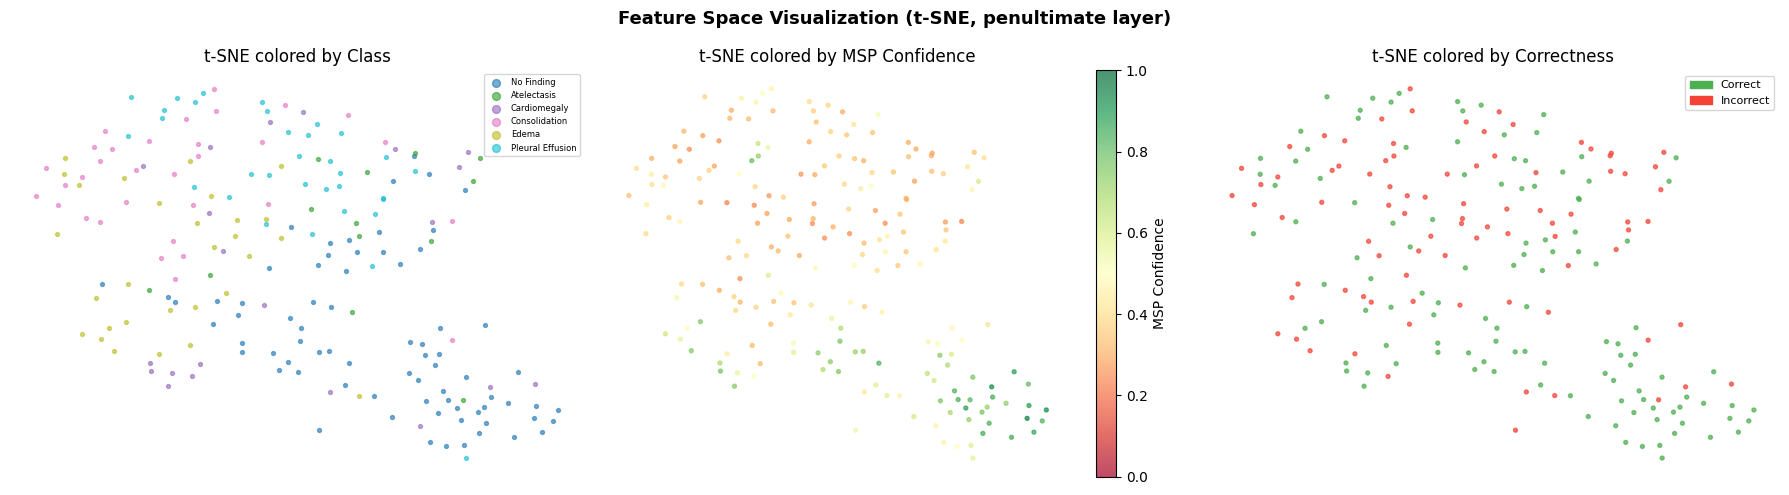

Saved: ./results/tsne_features.png


In [ ]:
fig = plt.figure(figsize=(18, 5))
axes = fig.subplots(1, 3)

cmap_class = plt.colormaps.get_cmap("tab10").resampled(config["num_classes"])
for c in range(config["num_classes"]):
    mask = feat_labels_trunc == c
    axes[0].scatter(emb[mask, 0], emb[mask, 1], s=8, alpha=0.6,
                    color=cmap_class(c), label=CLASS_NAMES[c])
axes[0].set_title("t-SNE colored by Class")
axes[0].legend(fontsize=6, markerscale=2, loc="upper right")
axes[0].axis("off")

sc = axes[1].scatter(emb[:, 0], emb[:, 1], c=feat_conf, cmap="RdYlGn", s=8, alpha=0.7, vmin=0, vmax=1)
plt.colorbar(sc, ax=axes[1], label="MSP Confidence")
axes[1].set_title("t-SNE colored by MSP Confidence")
axes[1].axis("off")

colors3 = ["#4CAF50" if c else "#F44336" for c in feat_correct]
axes[2].scatter(emb[:, 0], emb[:, 1], c=colors3, s=8, alpha=0.7)
from matplotlib.patches import Patch
axes[2].legend(handles=[Patch(color="#4CAF50", label="Correct"), Patch(color="#F44336", label="Incorrect")],
               fontsize=8)
axes[2].set_title("t-SNE colored by Correctness")
axes[2].axis("off")

plt.suptitle("Feature Space Visualization (t-SNE, penultimate layer)", fontsize=13, fontweight="bold")
plt.tight_layout()
p = os.path.join(config["results_dir"], "tsne_features.png")
plt.savefig(p, dpi=150); plt.show(); print(f"Saved: {p}")

## 19. Comprehensive AURC Comparison Table

In [ ]:
conditions = {
    "In-Dist (Clean)": res,
    "Noise (mild)":     corrupt_results["Noise (mild)"]["res"],
    "Noise (severe)":   corrupt_results["Noise (severe)"]["res"],
    "Blur (mild)":      corrupt_results["Blur (mild)"]["res"],
    "Blur (severe)":    corrupt_results["Blur (severe)"]["res"],
    "Brightness (sev.)": corrupt_results["Brightness (sev.)"]["res"],
}

scorer_fns = {
    "MSP":        lambda p, l: score_msp(p),
    "Margin":     lambda p, l: score_margin(p),
    "Entropy":    lambda p, l: score_entropy(p),
    "Energy":     lambda p, l: score_energy(p, l),
    "ODIN (T=1k)": lambda p, l: score_odin_temp(p, l, T=1000.0),
    "Doctor":     lambda p, l: score_doctor(p),
    "RLconf-2":   lambda p, l: score_rlconf_k(p, l, K=2),
    "RLconf-5":   lambda p, l: score_rlconf_k(p, l, K=5),
    "RLgeo-3":    lambda p, l: score_rlgeo_m(p, l, M=3),
    "MC-MSP":     None,
}

rows = []
for cond_name, r_data in conditions.items():
    cond_acc  = accuracy_score(r_data["labels"], r_data["preds"])
    row = {"Condition": cond_name, "Accuracy": f"{cond_acc:.4f}"}

    for sname, sfn in scorer_fns.items():
        if sfn is None:
            if cond_name == "In-Dist (Clean)":
                m = selective_metrics(mc_res["preds"], mc_res["labels"], mc_res["mc_msp"])
            else:
                row[sname] = "n/a"
                continue
        else:
            s = sfn(r_data["probs"], r_data["logits"])
            m = selective_metrics(r_data["preds"], r_data["labels"], s)
        row[sname] = f"{aurc(m):.5f}"
    rows.append(row)

comparison_df = pd.DataFrame(rows)
comparison_df.set_index("Condition", inplace=True)

csv_path = os.path.join(config["results_dir"], "aurc_comparison_table.csv")
comparison_df.to_csv(csv_path)
print(f"Saved: {csv_path}\n")
print(comparison_df.to_string())

Saved: ./results/aurc_comparison_table.csv

                  Accuracy      MSP   Margin  Entropy   Energy ODIN (T=1k)   Doctor RLconf-2 RLconf-5  RLgeo-3   MC-MSP
Condition                                                                                                              
In-Dist (Clean)     0.5743  0.26731  0.27547  0.27182  0.29218     0.26973  0.27076  0.28099  0.29398  0.27521  0.34223
Noise (mild)        0.4505  0.35321  0.36017  0.34495  0.36073     0.33649  0.35956  0.36309  0.35148  0.35715      n/a
Noise (severe)      0.1238  0.83116  0.82264  0.85251  0.84356     0.84003  0.82611  0.82102  0.84149  0.82375      n/a
Blur (mild)         0.5594  0.29393  0.29732  0.29688  0.33687     0.30037  0.29447  0.29899  0.31256  0.29936      n/a
Blur (severe)       0.4257  0.33966  0.34546  0.34672  0.37046     0.34384  0.34023  0.34710  0.36158  0.34084      n/a
Brightness (sev.)   0.5495  0.28016  0.29037  0.28330  0.33597     0.28837  0.28355  0.28861  0.30559  0.28207      

/tmp/ipykernel_12833/1647068806.py:46: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(metrics["risk"], metrics["coverage"]))
/tmp/ipykernel_12833/1647068806.py:46: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(metrics["risk"], metrics["coverage"]))
/tmp/ipykernel_12833/1647068806.py:46: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(metrics["risk"], metrics["coverage"]))
/tmp/ipykernel_12833/1647068806.py:46: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(metrics["risk"], metrics["coverage"]))
/tmp/ipykernel_12833/1647068806.py:46: Deprecati

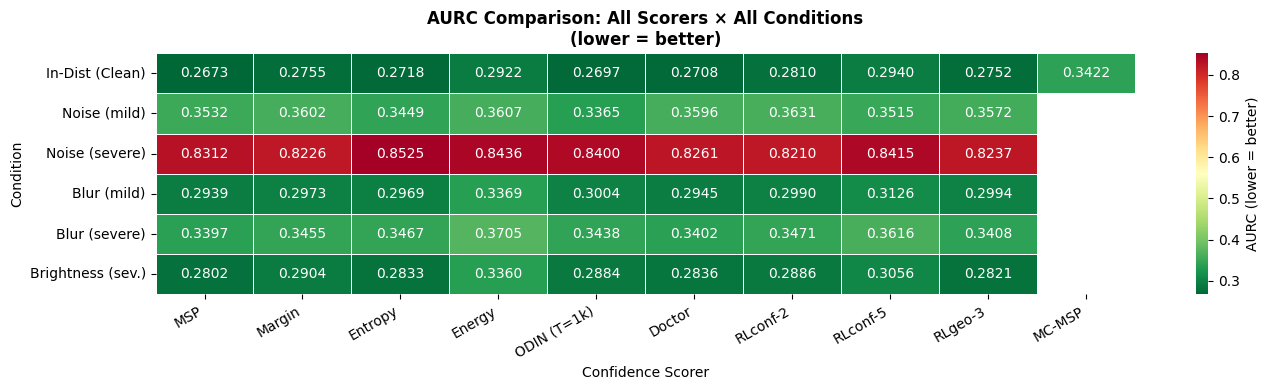

Saved: ./results/aurc_heatmap.png


In [ ]:
numeric_cols = [c for c in comparison_df.columns if c != "Accuracy"]
heatmap_data = comparison_df[numeric_cols].replace("n/a", np.nan).astype(float)

plt.figure(figsize=(14, 4))
sns.heatmap(heatmap_data, annot=True, fmt=".4f", cmap="RdYlGn_r",
            linewidths=0.5, cbar_kws={"label": "AURC (lower = better)"})
plt.title("AURC Comparison: All Scorers × All Conditions\n(lower = better)",
          fontsize=12, fontweight="bold")
plt.xlabel("Confidence Scorer")
plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
p = os.path.join(config["results_dir"], "aurc_heatmap.png")
plt.savefig(p, dpi=150); plt.show(); print(f"Saved: {p}")

## 20. Optimal Threshold Selection
Given a target coverage or a target risk, find the confidence threshold that achieves it.

In [ ]:
def find_threshold_for_coverage(scores, target_coverage):
    n   = len(scores)
    k   = int(target_coverage * n)
    sorted_scores = np.sort(scores)[::-1]
    if k >= n:
        return sorted_scores[-1]
    return sorted_scores[k]


def find_threshold_for_risk(preds, labels, scores, target_risk, coverages=None):
    if coverages is None:
        coverages = np.linspace(0.05, 1.0, 200)
    m = selective_metrics(preds, labels, scores, coverages)
    idx = np.where(m["risk"] <= target_risk)[0]
    if len(idx) == 0:
        return None, None
    best = idx[0]
    thresh = find_threshold_for_coverage(scores, m["coverage"][best])
    return m["coverage"][best], thresh


target_risk     = 0.05
target_coverage = 0.80

print(f"Threshold analysis for target risk = {target_risk:.2f} and target coverage = {target_coverage:.2f}\n")
print(f"{'Scorer':<15} {'Cov@risk5%':>12} {'Thresh@risk5%':>15} {'Thresh@cov80%':>15}")
print("-" * 60)

threshold_results = {}
for name, scores in advanced_scorers.items():
    cov_at_risk, thresh_for_risk = find_threshold_for_risk(preds, labels, scores, target_risk)
    thresh_for_cov = find_threshold_for_coverage(scores, target_coverage)

    cov_str   = f"{cov_at_risk:.3f}" if cov_at_risk is not None else "N/A"
    thresh_str = f"{thresh_for_risk:.4f}" if thresh_for_risk is not None else "N/A"
    print(f"{name:<15} {cov_str:>12} {thresh_str:>15} {thresh_for_cov:>15.4f}")

    threshold_results[name] = {
        "coverage_at_5pct_risk": cov_at_risk,
        "threshold_at_5pct_risk": thresh_for_risk,
        "threshold_at_80pct_cov": thresh_for_cov,
    }

Threshold analysis for target risk = 0.05 and target coverage = 0.80

Scorer            Cov@risk5%   Thresh@risk5%   Thresh@cov80%
------------------------------------------------------------
MSP                      N/A             N/A          0.3175
MSP-T (cal.)             N/A             N/A          0.3085
Margin                   N/A             N/A          0.0509
Entropy                  N/A             N/A         -1.5755
Energy                   N/A             N/A          2.1643
ODIN (T=1k)              N/A             N/A          0.1668
Doctor                   N/A             N/A         -0.5703
RLconf-2                 N/A             N/A          0.1914
RLconf-5                 N/A             N/A          1.4825
RLgeo-3                  N/A             N/A          0.4186


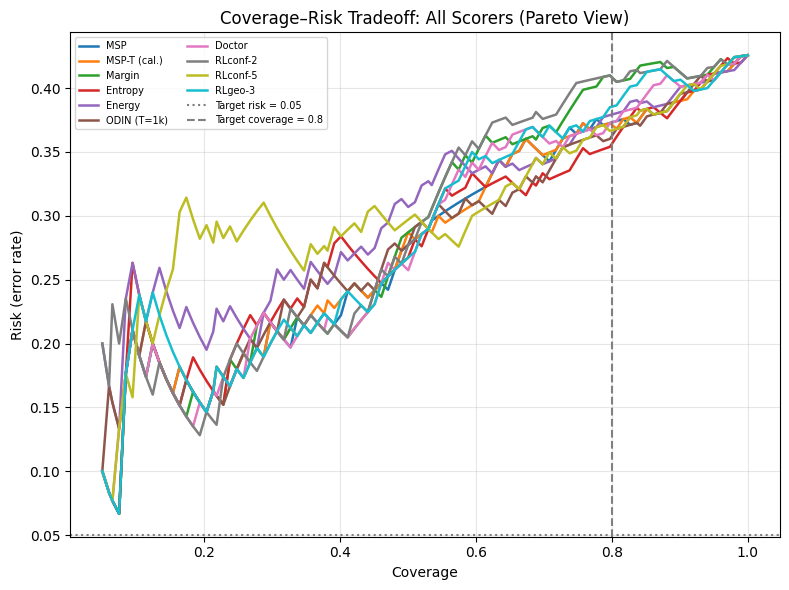

Saved: ./results/pareto_coverage_risk.png


In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
cmap_p = plt.colormaps.get_cmap("tab10").resampled(len(advanced_scorers))

for i, (name, scores) in enumerate(advanced_scorers.items()):
    m = selective_metrics(preds, labels, scores, coverages=np.linspace(0.05, 1.0, 100))
    ax.plot(m["coverage"], m["risk"], color=cmap_p(i), lw=1.8, label=name)

ax.axhline(target_risk, color="gray", linestyle=":", label=f"Target risk = {target_risk}")
ax.axvline(target_coverage, color="gray", linestyle="--", label=f"Target coverage = {target_coverage}")
ax.set_xlabel("Coverage")
ax.set_ylabel("Risk (error rate)")
ax.set_title("Coverage–Risk Tradeoff: All Scorers (Pareto View)")
ax.legend(fontsize=7, ncol=2)
ax.grid(alpha=0.3)

plt.tight_layout()
p = os.path.join(config["results_dir"], "pareto_coverage_risk.png")
plt.savefig(p, dpi=150); plt.show(); print(f"Saved: {p}")

## 21. Final Summary and Export

In [ ]:
# Build final metrics dictionary
final_metrics = {
    "dataset":              config["dataset"],
    "model":                config["model_name"],
    "epochs":               config["epochs"],
    "seed":                 config["seed"],

    "best_val_acc":         float(best_val_acc),
    "test_acc":             float(test_acc),
    "balanced_acc":         float(bal_acc),
    "mc_dropout_test_acc":  float(mc_acc),

    "ece_before_calibration": float(baseline_ece),
    "ece_after_calibration":  float(ece_after),
    "temperature":            float(T_opt),

    "aurc_clean": {name: float(aurc(selective_metrics(preds, labels, s)))
                   for name, s in advanced_scorers.items()},

    "aurc_noise_severe": {
        name: float(aurc(selective_metrics(
            corrupt_results["Noise (severe)"]["res"]["preds"],
            corrupt_results["Noise (severe)"]["res"]["labels"],
            sfn(corrupt_results["Noise (severe)"]["res"]["probs"],
                corrupt_results["Noise (severe)"]["res"]["logits"])
        )))
        for name, sfn in [("MSP",      lambda p,l: score_msp(p)),
                            ("RLconf-2", lambda p,l: score_rlconf_k(p,l,K=2)),
                            ("Energy",   lambda p,l: score_energy(p,l))]
    },

    "n_type_A_errors": int(type_A_mask.sum()),
    "n_type_C_errors": int(type_C_mask.sum()),
    "n_type_B_errors": int(type_B_mask.sum()),

    "waurc_clean": {name: float(weighted_aurc(d["weighted"]))
                    for name, d in w_sc_results.items()},

    "threshold_analysis": {
        name: {k: (float(v) if v is not None else None) for k, v in d.items()}
        for name, d in threshold_results.items()
    },
}

json_path = os.path.join(config["results_dir"], "final_metrics.json")
with open(json_path, "w") as f:
    json.dump(final_metrics, f, indent=2)
print(f"Saved: {json_path}")

print("\n" + "="*60)
print("FINAL SUMMARY")
print(f"Dataset:            {config['dataset']}")
print(f"Model:              {config['model_name']}")
print(f"Test accuracy:      {test_acc:.4f}")
print(f"Balanced accuracy:  {bal_acc:.4f}")
print(f"ECE (before/after): {baseline_ece:.4f} → {ece_after:.4f} (T={T_opt:.3f})")
print(f"\nAURC on clean test set:")
for name, val in final_metrics["aurc_clean"].items():
    print(f"  {name:<15}: {val:.5f}")
print(f"\nError type counts: A={type_A_mask.sum()} / C={type_C_mask.sum()} / B={type_B_mask.sum()}")


Saved: ./results/final_metrics.json

FINAL SUMMARY
Dataset:            chexpert_small
Model:              resnet18
Test accuracy:      0.5743
Balanced accuracy:  0.4896
ECE (before/after): 0.1045 → 0.1275 (T=1.063)

AURC on clean test set:
  MSP            : 0.26731
  MSP-T (cal.)   : 0.26822
  Margin         : 0.27547
  Entropy        : 0.27182
  Energy         : 0.29218
  ODIN (T=1k)    : 0.26973
  Doctor         : 0.27076
  RLconf-2       : 0.28099
  RLconf-5       : 0.29398
  RLgeo-3        : 0.27521

Error type counts: A=86 / C=100 / B=61


/tmp/ipykernel_12833/1647068806.py:46: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(metrics["risk"], metrics["coverage"]))
/tmp/ipykernel_12833/2875898784.py:43: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(wm["weighted_risk"], wm["coverage"]))
